# Pipeline Results Visualization Notebook

This notebook is an interactive refactor of the pipeline plotting script.

It is organized by pipeline stage so you can run, inspect, and edit each figure as you iterate:
1. Baseline flow outputs
2. Flood disruption outputs
3. Direct damage outputs
4. Rerouting and recovery outputs

Optional hazard map code is included at the end for future hazard layers.

In [25]:
from __future__ import annotations

import ast
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import contextily as ctx
    HAS_CONTEXTILY = True
except ImportError:
    HAS_CONTEXTILY = False

plt.style.use("default")

In [3]:
# Parameters to update for each run
VARIANT = os.getenv("NIRD_RESULTS_VARIANT", "od_inflation_100x")
DEPTH_KEY = 30
FLOOD_KEY = 1
RECOVERY_DAYS = [0, 7, 14, 30, 60, 90, 120, 150, 180]

# Resolve repository root robustly
root = Path.cwd()
while root != root.parent and not (root / "pyproject.toml").exists():
    root = root.parent

results_root = root / "sandbox" / "results"
fig_root = results_root / "figures" / VARIANT

step1_fig_dir = fig_root / "step1_base"
step2_fig_dir = fig_root / "step2_disruption"
step3_fig_dir = fig_root / "step3_damage"
step4_fig_dir = fig_root / "step4_rerouting"
for p in [step1_fig_dir, step2_fig_dir, step3_fig_dir, step4_fig_dir]:
    p.mkdir(parents=True, exist_ok=True)

paths = {
    "base_odpfc": results_root / "base_scenario" / VARIANT / "odpfc.pq",
    "base_edge_flows": results_root / "base_scenario" / VARIANT / "edge_flows.gpq",
    "disruption_intersections": results_root / "disruption_analysis" / VARIANT / str(DEPTH_KEY) / "intersections" / f"intersections_{FLOOD_KEY}.pq",
    "disruption_links": results_root / "disruption_analysis" / VARIANT / str(DEPTH_KEY) / "links" / f"road_links_{FLOOD_KEY}.gpq",
    "damage_csv": results_root / "damage_analysis" / VARIANT / f"intersections_{FLOOD_KEY}_with_damage_values.csv",
    "rerouting_costs": results_root / "rerouting_analysis" / VARIANT / str(DEPTH_KEY) / str(FLOOD_KEY) / "cost_matrix_by_scenario.csv",
    "rerouting_dir": results_root / "rerouting_analysis" / VARIANT / str(DEPTH_KEY) / str(FLOOD_KEY),
}

for k, v in paths.items():
    print(f"{k}: {v}")
    if k != "rerouting_dir":
        print(f"  exists: {v.exists()}")

base_odpfc: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\results\base_scenario\od_inflation_100x\odpfc.pq
  exists: True
base_edge_flows: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\results\base_scenario\od_inflation_100x\edge_flows.gpq
  exists: True
disruption_intersections: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\results\disruption_analysis\od_inflation_100x\30\intersections\intersections_1.pq
  exists: True
disruption_links: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\results\disruption_analysis\od_inflation_100x\30\links\road_links_1.gpq
  exists: True
damage_csv: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\results\damage_analysis\od_inflation_100x\intersections_1_with_damage_values.csv
  exists: True
rerouting_costs: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\results\rerouting_analysis\od_inflation_100x\30\1\cost_matrix_by_scenario.csv
  exists: True
rerouting_dir: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean

In [4]:
def save_figure(fig: plt.Figure, out_dir: Path, stem: str) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"{stem}.png", dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(out_dir / f"{stem}.pdf", bbox_inches="tight", facecolor="white")

def parse_path_edges(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, (list, tuple, set)):
        return [str(v) for v in value]
    if isinstance(value, np.ndarray):
        values = value.tolist()
        if values and all(isinstance(v, str) and len(v) == 1 for v in values):
            s = "".join(values)
            if s.startswith("[") and s.endswith("]"):
                try:
                    parsed = ast.literal_eval(s)
                    if isinstance(parsed, (list, tuple, set, np.ndarray)):
                        return [str(v) for v in parsed]
                except Exception:
                    pass
        return [str(v) for v in values]
    if isinstance(value, str):
        s = value.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple, set, np.ndarray)):
                    return [str(v) for v in parsed]
            except Exception:
                pass
        return [tok.strip() for tok in s.split(",") if tok.strip()]
    return [str(value)]

def compute_path_distance_miles(odpfc_df: pd.DataFrame, edges_gdf: gpd.GeoDataFrame) -> pd.Series:
    edge_len_col = "length_mile" if "length_mile" in edges_gdf.columns else "length"
    edge_lengths = edges_gdf.assign(e_id=edges_gdf["e_id"].astype(str)).set_index("e_id")[edge_len_col].astype(float)
    if edge_len_col == "length":
        edge_lengths = edge_lengths / 1609.34

    def _dist(path_val):
        edges = parse_path_edges(path_val)
        return float(sum(edge_lengths.get(str(e), 0.0) for e in edges))

    return odpfc_df["path"].apply(_dist)

In [28]:
# Load all data once
odpfc = pd.read_parquet(paths["base_odpfc"])
edge_flows = gpd.read_parquet(paths["base_edge_flows"])
intersections = pd.read_parquet(paths["disruption_intersections"])
road_links = gpd.read_parquet(paths["disruption_links"])
damage_df = pd.read_csv(paths["damage_csv"])
rerouting_costs = pd.read_csv(paths["rerouting_costs"]).sort_values("scenario")

print("Loaded shapes:")
print("  odpfc:", odpfc.shape)
print("  edge_flows:", edge_flows.shape)
print("  intersections:", intersections.shape)
print("  road_links:", road_links.shape)
print("  damage_df:", damage_df.shape)
print("  rerouting_costs:", rerouting_costs.shape)

Loaded shapes:
  odpfc: (364, 7)
  edge_flows: (4541, 35)
  intersections: (349667, 8)
  road_links: (4541, 29)
  damage_df: (229760, 67)
  rerouting_costs: (9, 7)


## Step 0. Study area context map

A simple basemap context figure showing the study area extent before the analysis panels.

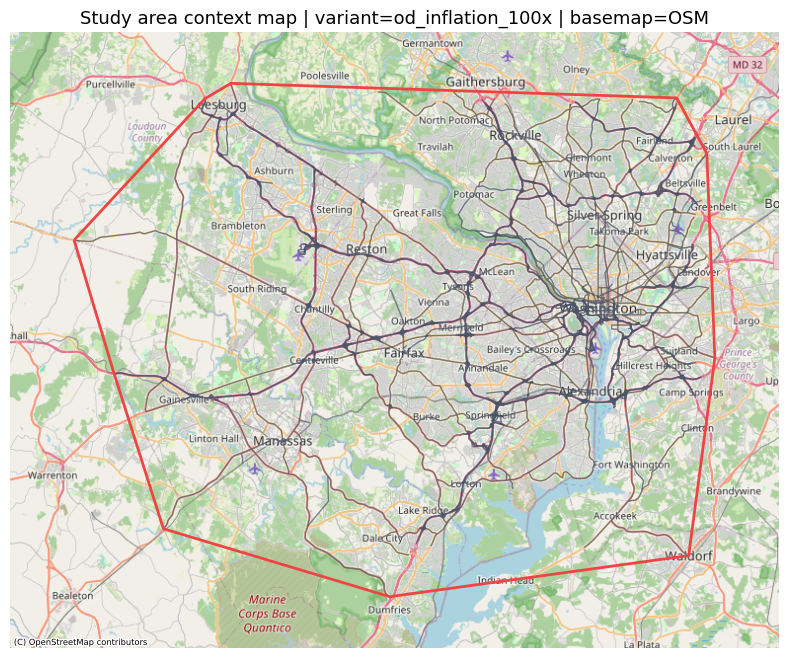

In [46]:
# Study area basemap (context only) -- prefer OSM tiles
study_fig_dir = fig_root / "step0_study_area"
study_fig_dir.mkdir(parents=True, exist_ok=True)

study_area = edge_flows[["geometry"]].copy()
if study_area.crs is None:
    study_area = study_area.set_crs("EPSG:4326")

# Use Web Mercator for tile basemap compatibility
study_area_3857 = study_area.to_crs("EPSG:3857")

# Build footprint and padded extent
footprint = study_area_3857.geometry.union_all().convex_hull if hasattr(study_area_3857.geometry, "union_all") else study_area_3857.unary_union.convex_hull
minx, miny, maxx, maxy = footprint.bounds
pad_x = (maxx - minx) * 0.10 if maxx > minx else 1000
pad_y = (maxy - miny) * 0.10 if maxy > miny else 1000
xlim = (minx - pad_x, maxx + pad_x)
ylim = (miny - pad_y, maxy + pad_y)

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("#e5e7eb")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

# Always draw a faint network so map is never empty
study_area_3857.plot(ax=ax, linewidth=0.6, color="#9ca3af", alpha=0.35, zorder=3)

basemap_label = "OSM"
osm_error = None

if HAS_CONTEXTILY:
    try:
        # IMPORTANT: do not pass `crs` here since axis is already EPSG:3857.
        # Passing `crs` can trigger tile warping and fail on missing PROJ db.
        ctx.add_basemap(
            ax,
            source=ctx.providers.OpenStreetMap.Mapnik,
            zoom="auto",
            attribution_size=6,
        )
    except Exception as e:
        osm_error = str(e)
        basemap_label = "OSM failed; offline fallback"

# Offline fallback if OSM tile request fails
if basemap_label != "OSM":
    local_study_candidates = [
        root / "sandbox" / "fairfax_soge_clusters_toy" / "study_area" / "fairfax_study_area.geojson",
        root / "sandbox" / "fairfax_baseline" / "study_area" / "fairfax_study_area.geojson",
        root / "sandbox" / "fairfax_soge_clusters_toy" / "study_area" / "fairfax_study_area.gpkg",
        root / "sandbox" / "fairfax_baseline" / "study_area" / "fairfax_study_area.gpkg",
    ]
    loaded = False
    for p in local_study_candidates:
        if p.exists():
            try:
                study_poly = gpd.read_file(p).to_crs("EPSG:3857")
                study_poly.plot(ax=ax, color="#f8fafc", edgecolor="#93c5fd", linewidth=1.0, alpha=0.95, zorder=0)
                loaded = True
                break
            except Exception:
                continue
    if not loaded:
        ax.set_facecolor("#f3f4f6")

# Draw network + boundary on top
study_area_3857.plot(ax=ax, linewidth=1.0, color="#475569", alpha=0.65, zorder=4)
gpd.GeoSeries([footprint], crs=study_area_3857.crs).boundary.plot(ax=ax, color="#ef4444", linewidth=2.0, zorder=5)

ax.set_title(f"Study area context map | variant={VARIANT} | basemap={basemap_label}", fontsize=13)
if osm_error:
    ax.text(0.01, 0.01, f"OSM error: {osm_error[:120]}", transform=ax.transAxes, fontsize=7, color="#334155")
ax.set_axis_off()

save_figure(fig, study_fig_dir, "step0_study_area_basemap")
plt.show()

## Step 1. Baseline flow visuals

### Baseline flow analysis (4 plots)
- **Plot 1 (top-left)**: Distribution of OD flow volumes in vehicles per day (raw daily volumes, no scaling)
- **Plot 2 (top-right)**: Relationship between route distance and flow, with fitted log-linear trend (longer routes typically carry less flow)
- **Plot 3 (bottom-left)**: The 12 largest origin-destination pairs by volume
- **Plot 4 (bottom-right)**: Spatial view of baseline network flows, where line thickness scales with accumulated flow

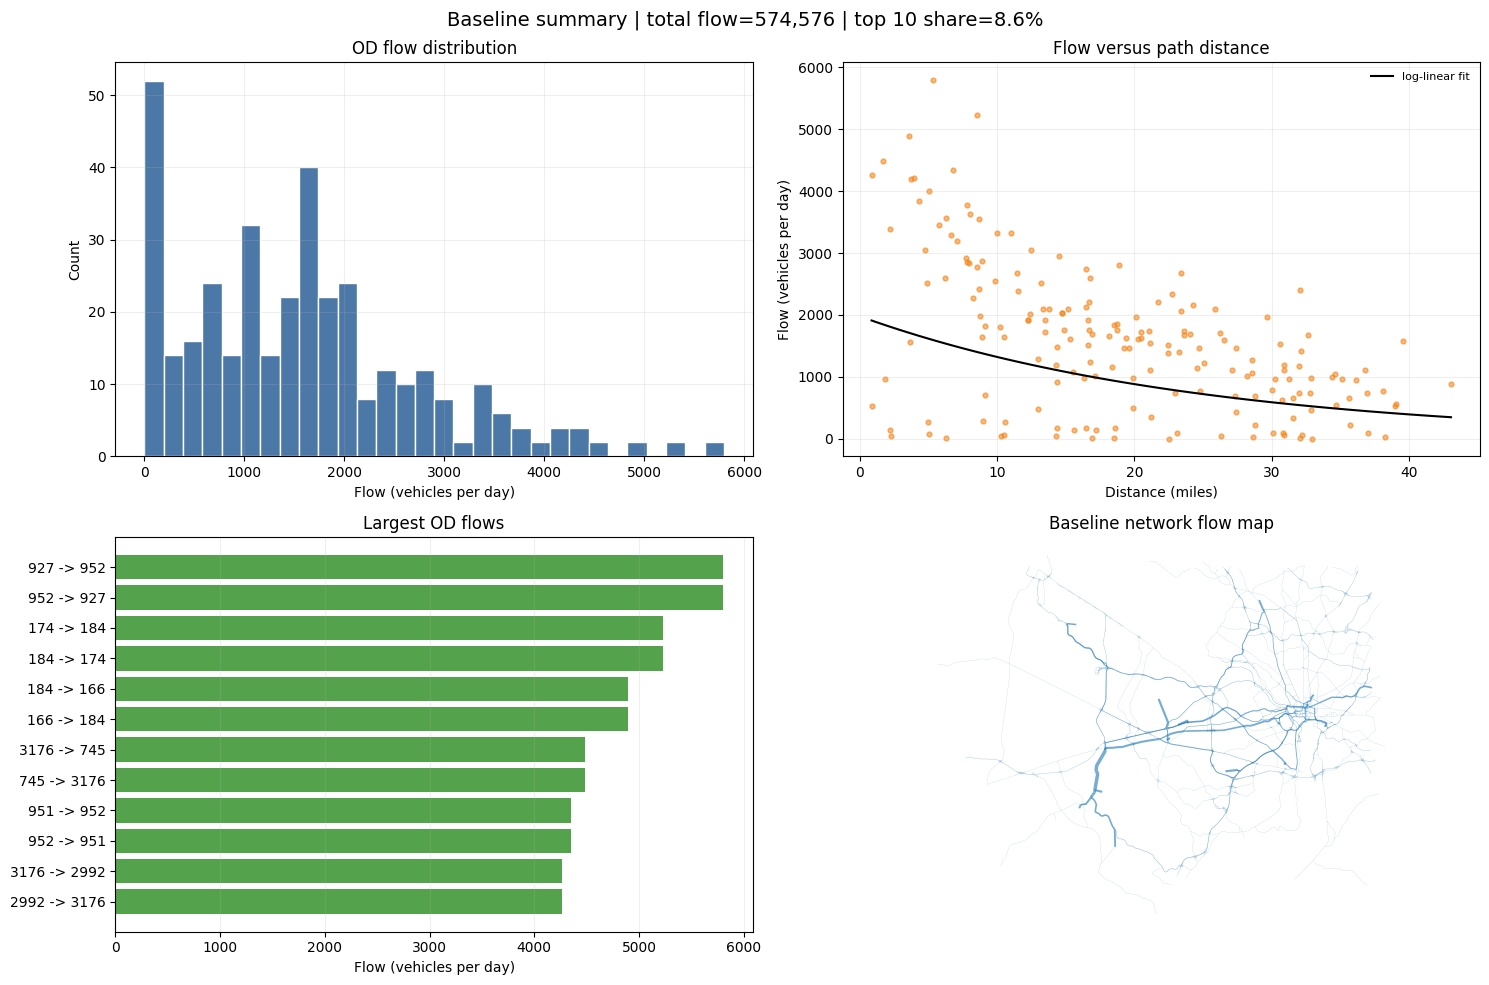

In [15]:
flow_col = "flow" if "flow" in odpfc.columns else "Car21"
odpfc_step1 = odpfc.copy()
odpfc_step1["distance_miles"] = compute_path_distance_miles(odpfc_step1, edge_flows)
valid = odpfc_step1[(odpfc_step1[flow_col] > 0) & (odpfc_step1["distance_miles"] > 0)].copy()

total_flow = float(odpfc_step1[flow_col].sum())
top_share = float(odpfc_step1[flow_col].nlargest(min(10, len(odpfc_step1))).sum() / total_flow) if total_flow > 0 else np.nan

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

axes[0].hist(odpfc_step1[flow_col].astype(float), bins=30, color="#4c78a8", edgecolor="white")
axes[0].set_title("OD flow distribution")
axes[0].set_xlabel("Flow (vehicles per day)")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.2)

if len(valid) > 4:
    axes[1].scatter(valid["distance_miles"], valid[flow_col], s=12, alpha=0.35, color="#f58518")
    slope, intercept = np.polyfit(valid["distance_miles"].astype(float), np.log1p(valid[flow_col].astype(float)), 1)
    x = np.linspace(valid["distance_miles"].min(), valid["distance_miles"].max(), 100)
    y = np.expm1(intercept + slope * x)
    axes[1].plot(x, y, color="black", linewidth=1.5, label="log-linear fit")
    axes[1].legend(frameon=False, fontsize=8)
    axes[1].set_title("Flow versus path distance")
    axes[1].set_xlabel("Distance (miles)")
    axes[1].set_ylabel("Flow (vehicles per day)")
    axes[1].grid(True, alpha=0.2)
else:
    axes[1].text(0.5, 0.5, "Not enough valid rows for distance plot", ha="center", va="center")
    axes[1].set_axis_off()

top_od = odpfc_step1.sort_values(flow_col, ascending=False).head(12).copy()
top_od["od_pair"] = top_od["origin_node"].astype(str) + " -> " + top_od["destination_node"].astype(str)
axes[2].barh(top_od["od_pair"].iloc[::-1], top_od[flow_col].iloc[::-1], color="#54a24b")
axes[2].set_title("Largest OD flows")
axes[2].set_xlabel("Flow (vehicles per day)")
axes[2].grid(True, axis="x", alpha=0.2)

map_df = edge_flows.copy()
map_df["acc_flow"] = pd.to_numeric(map_df["acc_flow"], errors="coerce").fillna(0.0)
map_df["linewidth"] = 0.1 + 2.4 * (map_df["acc_flow"] / max(map_df["acc_flow"].max(), 1.0))
if map_df.crs:
    map_df = map_df.to_crs("EPSG:4326")
map_df.plot(ax=axes[3], linewidth=map_df["linewidth"], color="#1f77b4", alpha=0.6)
axes[3].set_title("Baseline network flow map")
axes[3].set_axis_off()

fig.suptitle(f"Baseline summary | total flow={total_flow:,.0f} | top 10 share={top_share:.1%}", fontsize=14)
fig.tight_layout()
save_figure(fig, step1_fig_dir, "step1_baseline_summary")
plt.show()

## Step 2. Flood disruption visuals

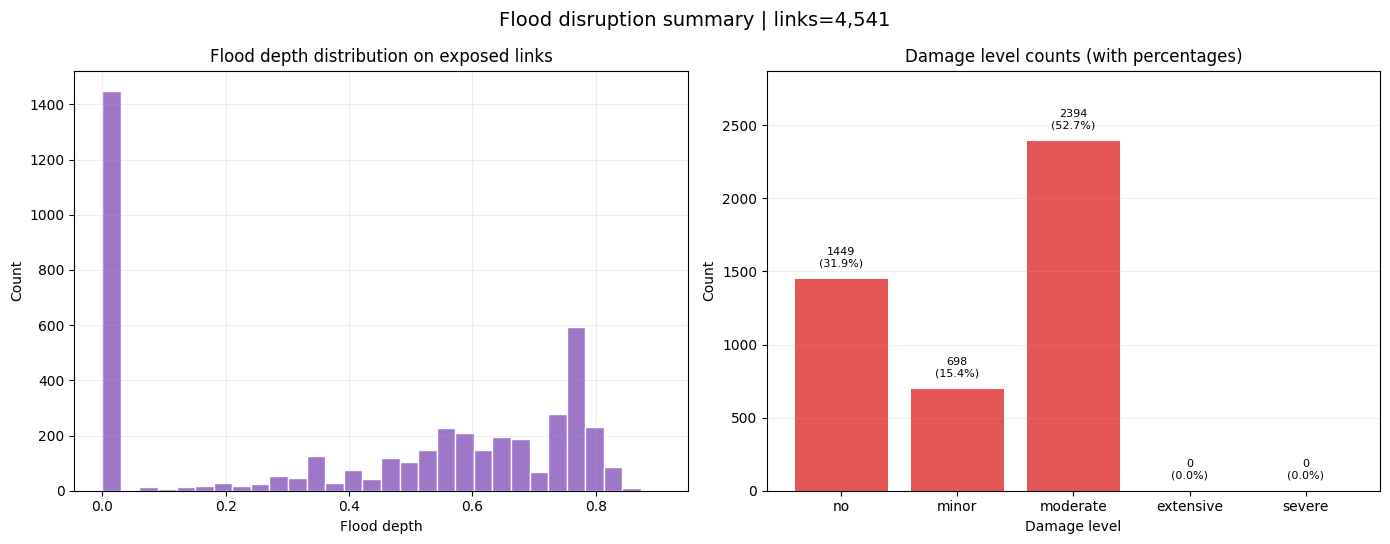

In [10]:
road_links_step2 = road_links.copy()
intersections_step2 = intersections.copy()

flood_col = "flood_depth_max" if "flood_depth_max" in road_links_step2.columns else None
if flood_col is None:
    flood_col = next((c for c in road_links_step2.columns if c.startswith("flood_depth")), None)
if flood_col is None:
    road_links_step2["flood_depth_value"] = np.nan
    flood_col = "flood_depth_value"

damage_level_dict = {
    "no": 0,
    "minor": 1,
    "moderate": 2,
    "extensive": 3,
    "severe": 4,
}
damage_level_order = [0, 1, 2, 3, 4]
damage_level_label_by_num = {v: k for k, v in damage_level_dict.items()}

damage_level_col = "damage_level_max" if "damage_level_max" in road_links_step2.columns else next((c for c in road_links_step2.columns if c.startswith("damage_level")), None)
road_links_step2[flood_col] = pd.to_numeric(road_links_step2[flood_col], errors="coerce")

# Keep this summary focused on the two comparable metrics across scales:
# 1) flood depth distribution, 2) damage level count + percentage
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel A: flood depth distribution
road_links_step2[flood_col].dropna().plot(kind="hist", bins=30, color="#9e77c9", edgecolor="white", ax=axes[0])
axes[0].set_title("Flood depth distribution on exposed links")
axes[0].set_xlabel("Flood depth (m)")
axes[0].set_ylabel("Count (links)")
axes[0].grid(True, alpha=0.2)

# Panel B: damage levels in fixed 0->4 order, including zeros
if damage_level_col and damage_level_col in road_links_step2.columns:
    damage_raw = road_links_step2[damage_level_col]
    damage_num = pd.to_numeric(damage_raw, errors="coerce")

    # If values are text labels, map them to 0..4.
    if damage_num.isna().all():
        damage_num = damage_raw.astype(str).str.strip().str.lower().map(damage_level_dict)

    counts = damage_num.value_counts(dropna=True).reindex(damage_level_order, fill_value=0).astype(int)
    denominator = int(counts.sum())
    pct = (counts / denominator * 100.0) if denominator > 0 else counts.astype(float)

    x_labels = [damage_level_label_by_num[i] for i in counts.index]
    bars = axes[1].bar(x_labels, counts.values, color="#e45756")
    axes[1].set_title("Damage level counts (with percentages)")
    axes[1].set_xlabel("Damage level")
    axes[1].set_ylabel("Count (links)")
    axes[1].grid(True, axis="y", alpha=0.2)

    ymax = max(counts.max(), 1)
    axes[1].set_ylim(0, ymax * 1.2)

    for bar, c, p in zip(bars, counts.values, pct.values):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ymax * 0.03,
            f"{int(c)}\n({p:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=8,
        )
else:
    axes[1].text(0.5, 0.5, "No damage level column found", ha="center", va="center")
    axes[1].set_axis_off()

n_links = int(len(road_links_step2))
fig.suptitle(f"Flood disruption summary | links={n_links:,}", fontsize=14)
fig.tight_layout()
save_figure(fig, step2_fig_dir, "step2_disruption_summary")
plt.show()

## Step 3. Direct damage visuals

### Direct damage analysis (4 plots)
- **Plot 1 (top-left)**: Distribution of asset damage values showing the spread of direct damages across all affected links
- **Plot 2 (top-right)**: Total damage aggregated by road classification (to identify which road types bear the most damage)
- **Plot 3 (bottom-left)**: Spatial map highlighting the most damaged links on the network, with line thickness proportional to damage value
- **Plot 4 (bottom-right)**: Distribution of damage fractions (normalized by asset value), showing percentage of asset value at risk
- **Note**: centroid connectors are excluded from the damage totals and damage plots because they are routing artifacts, not real roadway assets

In [31]:
damage_step3 = damage_df.copy()
damage_value_cols = [c for c in damage_step3.columns if c.endswith("_damage_value_mean")]
damage_fraction_cols = [c for c in damage_step3.columns if c.endswith("_damage_fraction")]

damage_step3["total_damage_value"] = damage_step3[damage_value_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1, min_count=1)
damage_step3["total_damage_fraction"] = damage_step3[damage_fraction_cols].apply(pd.to_numeric, errors="coerce").max(axis=1)
damage_step3["e_id"] = damage_step3["e_id"].astype(str)

road_class_lookup = road_links[["e_id"]].copy()
road_class_lookup["e_id"] = road_class_lookup["e_id"].astype(str)
if "road_classification_detail" in road_links.columns:
    road_class_lookup["road_classification_detail"] = road_links["road_classification_detail"].astype(str)
elif "Class_Description" in road_links.columns:
    road_class_lookup["road_classification_detail"] = road_links["Class_Description"].astype(str)
else:
    road_class_lookup["road_classification_detail"] = road_links.get("road_classification", pd.Series(index=road_links.index, dtype=object)).astype(str)
road_class_lookup["road_classification_detail"] = road_class_lookup["road_classification_detail"].replace({"nan": np.nan, "None": np.nan, "": np.nan})
road_class_lookup = road_class_lookup.drop_duplicates(subset=["e_id"])
damage_step3 = damage_step3.merge(road_class_lookup, on="e_id", how="left")

centroid_mask = damage_step3["road_classification_detail"].astype(str).str.contains("centroid connector", case=False, na=False) | damage_step3["road_classification"].astype(str).str.contains("centroid connector", case=False, na=False)
centroid_damage_rows = int(centroid_mask.sum())
if centroid_damage_rows > 0:
    damage_step3 = damage_step3.loc[~centroid_mask].copy()

damage_step3["road_classification_detail"] = damage_step3["road_classification_detail"].fillna(damage_step3["road_classification"])

# Shared per-link aggregates for the separate plot cells below.
damage_per_link_value = damage_step3.groupby("e_id", as_index=False).agg(
    total_damage_value=("total_damage_value", "sum"),
)
damage_per_link_fraction = damage_step3.groupby("e_id", as_index=False).agg(
    total_damage_fraction=("total_damage_fraction", "max"),
)

if "road_classification_detail" in damage_step3.columns:
    by_class = damage_step3.groupby("road_classification_detail", dropna=False)["total_damage_value"].sum().sort_values(ascending=False)
elif "road_classification" in damage_step3.columns:
    by_class = damage_step3.groupby("road_classification", dropna=False)["total_damage_value"].sum().sort_values(ascending=False)
else:
    by_class = pd.Series(dtype=float)

print("Prepared damage summary inputs:")
print("  damage_step3:", damage_step3.shape)
print("  damage_per_link_value:", damage_per_link_value.shape)
print("  damage_per_link_fraction:", damage_per_link_fraction.shape)
print("  road_classification available:", not by_class.empty)
print("  centroid connectors excluded from damage totals:", centroid_damage_rows)

Prepared damage summary inputs:
  damage_step3: (226898, 70)
  damage_per_link_value: (3078, 2)
  damage_per_link_fraction: (3078, 2)
  road_classification available: True
  centroid connectors excluded from damage totals: 2862


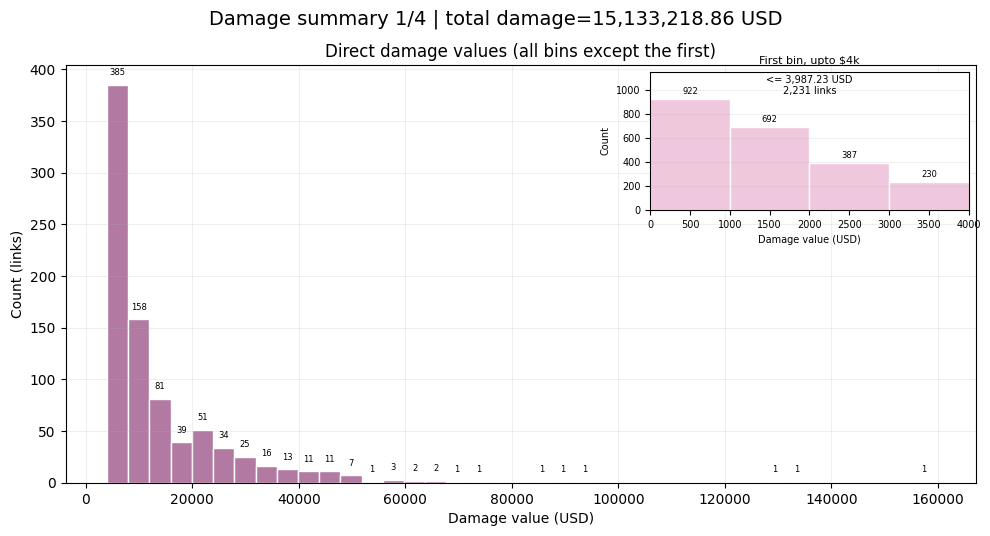

In [32]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Plot 1: damage value distribution with the first bin separated out
damage_values = damage_per_link_value["total_damage_value"].dropna().astype(float)
fig, ax = plt.subplots(figsize=(10, 5.5))

if len(damage_values) > 0:
    hist_counts, hist_edges = np.histogram(damage_values, bins=40)
    if len(hist_edges) > 1:
        first_bin_upper = hist_edges[1]
        first_bin_values = damage_values[damage_values <= first_bin_upper]
        remaining_values = damage_values[damage_values > first_bin_upper]
        total_count = int(len(damage_values))

        main_counts, main_edges, main_patches = ax.hist(
            remaining_values,
            bins=39,
            color="#b279a2",
            edgecolor="white",
        )
        ax.set_title("Direct damage values (all bins except the first)")
        ax.set_xlabel("Damage value (USD)")
        ax.set_ylabel("Count (links)")
        ax.grid(True, alpha=0.2)

        for patch, count in zip(main_patches, main_counts):
            if count <= 0:
                continue
            x = patch.get_x() + patch.get_width() / 2
            y = patch.get_height()
            ax.text(
                x,
                y + max(main_counts.max(), 1) * 0.02,
                f"{int(count)}",
                ha="center",
                va="bottom",
                fontsize=6,
                rotation=0,
            )

        inset = inset_axes(ax, width="35%", height="33%") #, loc="upper right", borderpad=1.0)
        inset_bins = np.arange(0, 5000, 1000)
        inset_counts, inset_edges, inset_patches = inset.hist(
            first_bin_values,
            bins=inset_bins,
            color="#f0c8de",
            edgecolor="white",
        )
        inset.set_title("First bin, upto $4k", fontsize=8)
        inset.set_xlabel("Damage value (USD)", fontsize=7)
        inset.set_ylabel("Count", fontsize=7)
        inset.tick_params(axis="x", labelsize=7)
        inset.tick_params(axis="y", labelsize=7)
        inset.grid(True, axis="y", alpha=0.2)
        inset.set_xlim(0, 4000)
        inset.set_ylim(0, max(inset_counts.max() if len(inset_counts) else 0, 1) * 1.25)

        for patch, count in zip(inset_patches, inset_counts):
            if count <= 0:
                continue
            x = patch.get_x() + patch.get_width() / 2
            y = patch.get_height()
            inset.text(
                x,
                y + max(inset_counts.max(), 1) * 0.03,
                f"{int(count)}",
                ha="center",
                va="bottom",
                fontsize=6,
            )

        inset.text(
            0.5,
            0.98,
            f"<= {first_bin_upper:,.2f} USD\n{len(first_bin_values):,} links",
            transform=inset.transAxes,
            ha="center",
            va="top",
            fontsize=7,
        )
        inset.set_position([0.61, 0.42, 0.30, 0.24])
    else:
        ax.hist(damage_values, bins=40, color="#c28fb3", edgecolor="white")
        ax.set_title("Direct damage values")
        ax.set_xlabel("Damage value (USD)")
        ax.set_ylabel("Count (links)")
        ax.grid(True, alpha=0.2)
else:
    ax.text(0.5, 0.5, "No damage values available", ha="center", va="center")
    ax.set_axis_off()

total_damage = float(damage_per_link_value["total_damage_value"].sum(skipna=True))
fig.suptitle(f"Damage summary 1/4 | total damage={total_damage:,.2f} USD", fontsize=14)
fig.subplots_adjust(top=0.88, right=0.98, left=0.07, bottom=0.12)
save_figure(fig, step3_fig_dir, "step3_damage_summary_1_damage_distribution")
plt.show()

C:\CondaTmp\ipykernel_27952\592667605.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, ha="right", fontsize=9)


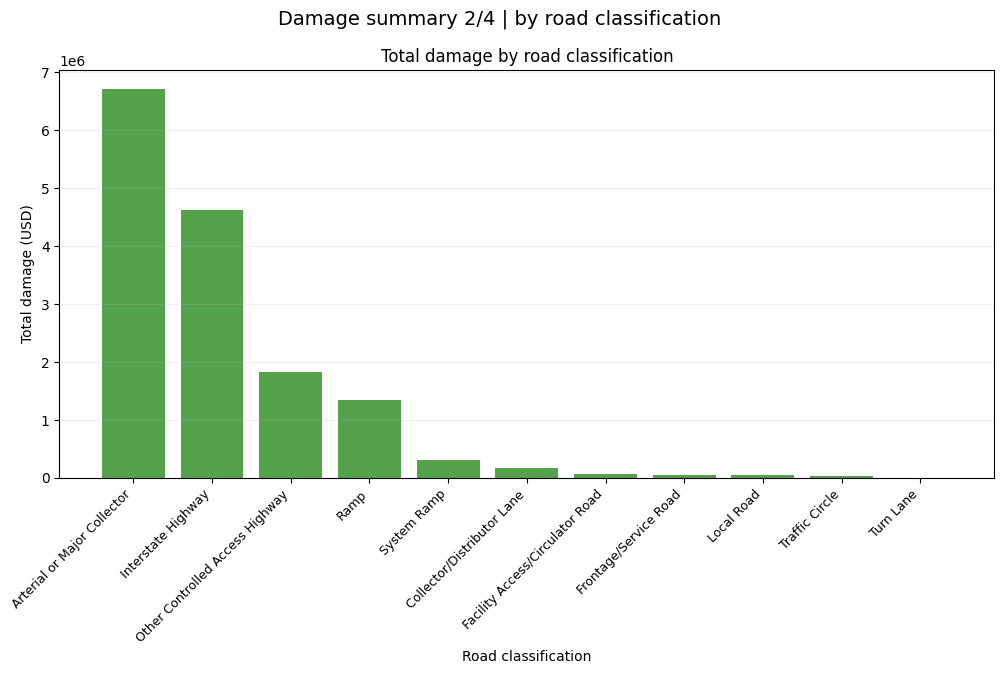

In [37]:
# Plot 2: total damage by road classification
fig, ax = plt.subplots(figsize=(11, 6))

classification_col = "road_classification_detail" if "road_classification_detail" in damage_step3.columns else "road_classification"
if classification_col in damage_step3.columns and not by_class.empty:
    ax.bar(by_class.index.astype(str), by_class.values, color="#54a24b")
    ax.set_title("Total damage by road classification")
    ax.set_xlabel("Road classification")
    ax.set_ylabel("Total damage (USD)")
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.grid(True, axis="y", alpha=0.2)
    # Clean up x-axis labels: wrap long names and improve readability
    labels = [label.get_text().replace("_", " ") for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels, ha="right", fontsize=9)
else:
    ax.text(0.5, 0.5, "Road classification not available", ha="center", va="center")
    ax.set_axis_off()

fig.suptitle("Damage summary 2/4 | by road classification", fontsize=14)
fig.subplots_adjust(bottom=0.2, left=0.1, right=0.95, top=0.88)
save_figure(fig, step3_fig_dir, "step3_damage_summary_2_road_classification")
plt.show()

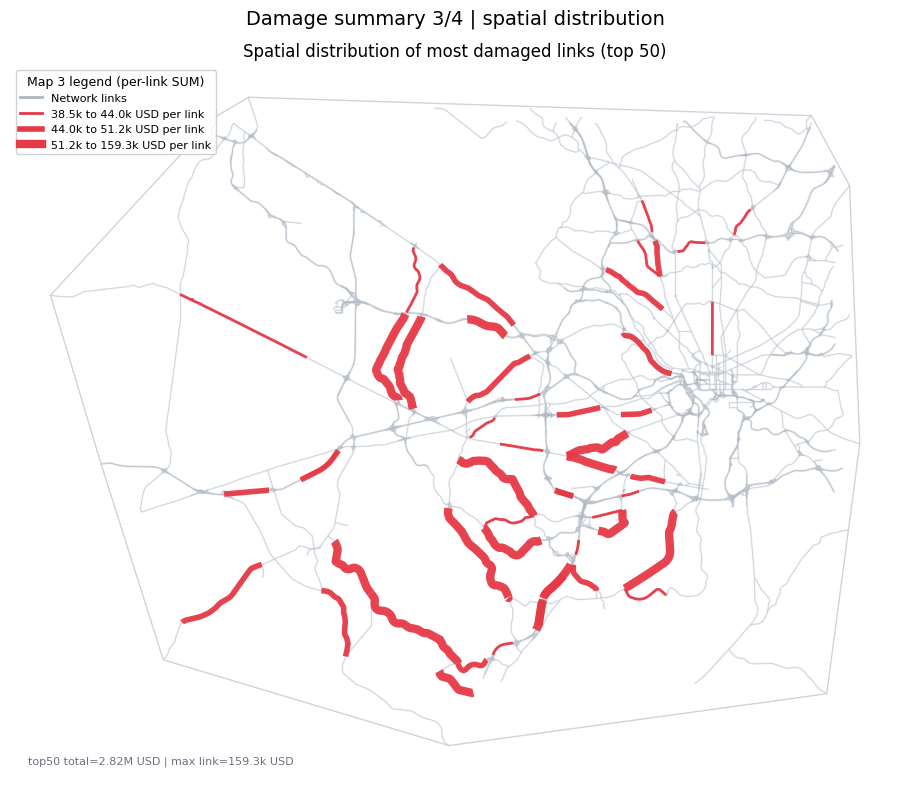

In [34]:
# Plot 3: spatial distribution of the most damaged links
top_damage = damage_per_link_value.sort_values("total_damage_value", ascending=False).head(50)
top50_total = float(top_damage["total_damage_value"].sum()) if len(top_damage) else 0.0
top50_max = float(top_damage["total_damage_value"].max()) if len(top_damage) else 0.0

links_spatial = road_links.copy()
links_spatial["e_id"] = links_spatial["e_id"].astype(str)

top_damage_spatial = links_spatial.merge(
    top_damage[["e_id", "total_damage_value"]],
    on="e_id",
    how="inner",
).copy()

if links_spatial.crs is not None and str(links_spatial.crs) != "EPSG:3857":
    map_df = links_spatial.to_crs("EPSG:3857")
    top_damage_spatial = top_damage_spatial.to_crs("EPSG:3857") if len(top_damage_spatial) > 0 else top_damage_spatial
else:
    map_df = links_spatial

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("#f5f7fa")
map_df.plot(ax=ax, linewidth=1.4, color="#d7dce2", alpha=0.45, zorder=1)
map_df.plot(ax=ax, linewidth=0.5, color="#aeb7c2", alpha=0.55, zorder=2)

try:
    footprint = map_df.geometry.union_all().convex_hull if hasattr(map_df.geometry, "union_all") else map_df.unary_union.convex_hull
    gpd.GeoSeries([footprint], crs=map_df.crs).boundary.plot(ax=ax, color="#c2cad4", linewidth=1.0, alpha=0.8, zorder=0)
except Exception:
    pass

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color="#aeb7c2", lw=2, label="Network links")]

if len(top_damage_spatial) > 0:
    vals = top_damage_spatial["total_damage_value"].astype(float).dropna().values

    if len(vals) > 1:
        edges = np.quantile(vals, [0.0, 0.33, 0.66, 1.0])
        edges = np.unique(edges)
        if len(edges) < 4:
            vmin, vmax = float(np.min(vals)), float(np.max(vals))
            if vmax > vmin:
                edges = np.linspace(vmin, vmax, 4)
            else:
                edges = np.array([vmin, vmin + 1e-6, vmin + 2e-6, vmin + 3e-6])
    else:
        v = float(vals[0])
        edges = np.array([v, v + 1e-6, v + 2e-6, v + 3e-6])

    n_classes = len(edges) - 1
    width_levels = np.linspace(2.0, 6.0, n_classes)

    top_damage_spatial = top_damage_spatial.copy()
    top_damage_spatial["damage_class"] = pd.cut(
        top_damage_spatial["total_damage_value"],
        bins=edges,
        labels=False,
        include_lowest=True,
        duplicates="drop",
    )

    for i in range(n_classes):
        class_gdf = top_damage_spatial[top_damage_spatial["damage_class"] == i]
        if len(class_gdf) == 0:
            continue
        class_gdf.plot(ax=ax, linewidth=width_levels[i], color="#e63946", alpha=0.95, zorder=3)
        lo = edges[i]
        hi = edges[i + 1]
        legend_elements.append(
            Line2D(
                [0],
                [0],
                color="#e63946",
                lw=float(width_levels[i]),
                label=f"{lo/1000:,.1f}k to {hi/1000:,.1f}k USD per link",
            )
        )
else:
    ax.text(0.5, 0.5, "No matching damaged links for spatial overlay", ha="center", va="center", transform=ax.transAxes)

ax.legend(
    handles=legend_elements,
    title="Map 3 legend (per-link SUM)",
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    fontsize=8,
    title_fontsize=9,
)

ax.text(
    0.02,
    0.02,
    f"top50 total={top50_total/1e6:.2f}M USD | max link={top50_max/1000:.1f}k USD",
    transform=ax.transAxes,
    fontsize=8,
    color="#6b7280",
)
ax.set_title("Spatial distribution of most damaged links (top 50)")
ax.set_axis_off()

fig.suptitle("Damage summary 3/4 | spatial distribution", fontsize=14)
fig.tight_layout()
save_figure(fig, step3_fig_dir, "step3_damage_summary_3_spatial_map")
plt.show()

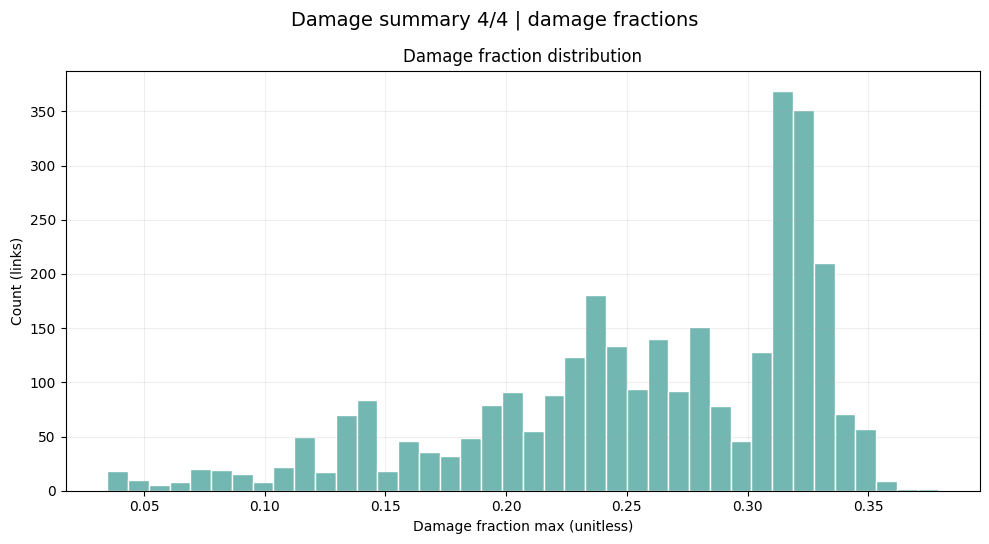

In [35]:
# Plot 4: damage fraction distribution
fig, ax = plt.subplots(figsize=(10, 5.5))

fraction_values = damage_per_link_fraction["total_damage_fraction"].dropna().astype(float)
if len(fraction_values) > 0:
    ax.hist(fraction_values, bins=40, color="#72b7b2", edgecolor="white")
    ax.set_title("Damage fraction distribution")
    ax.set_xlabel("Damage fraction max (unitless)")
    ax.set_ylabel("Count (links)")
    ax.grid(True, alpha=0.2)
else:
    ax.text(0.5, 0.5, "No damage fraction values available", ha="center", va="center")
    ax.set_axis_off()

fig.suptitle("Damage summary 4/4 | damage fractions", fontsize=14)
fig.tight_layout()
save_figure(fig, step3_fig_dir, "step3_damage_summary_4_damage_fractions")
plt.show()

### Step 3A. Per-link aggregation check (sum vs max)
This diagnostic compares two ways to collapse multiple damage rows per link (`e_id`):
- **Sum**: treats each row as an additive damage contribution
- **Max**: treats rows as alternative estimates and keeps the worst-case per link

## Step 4. Rerouting and recovery visuals

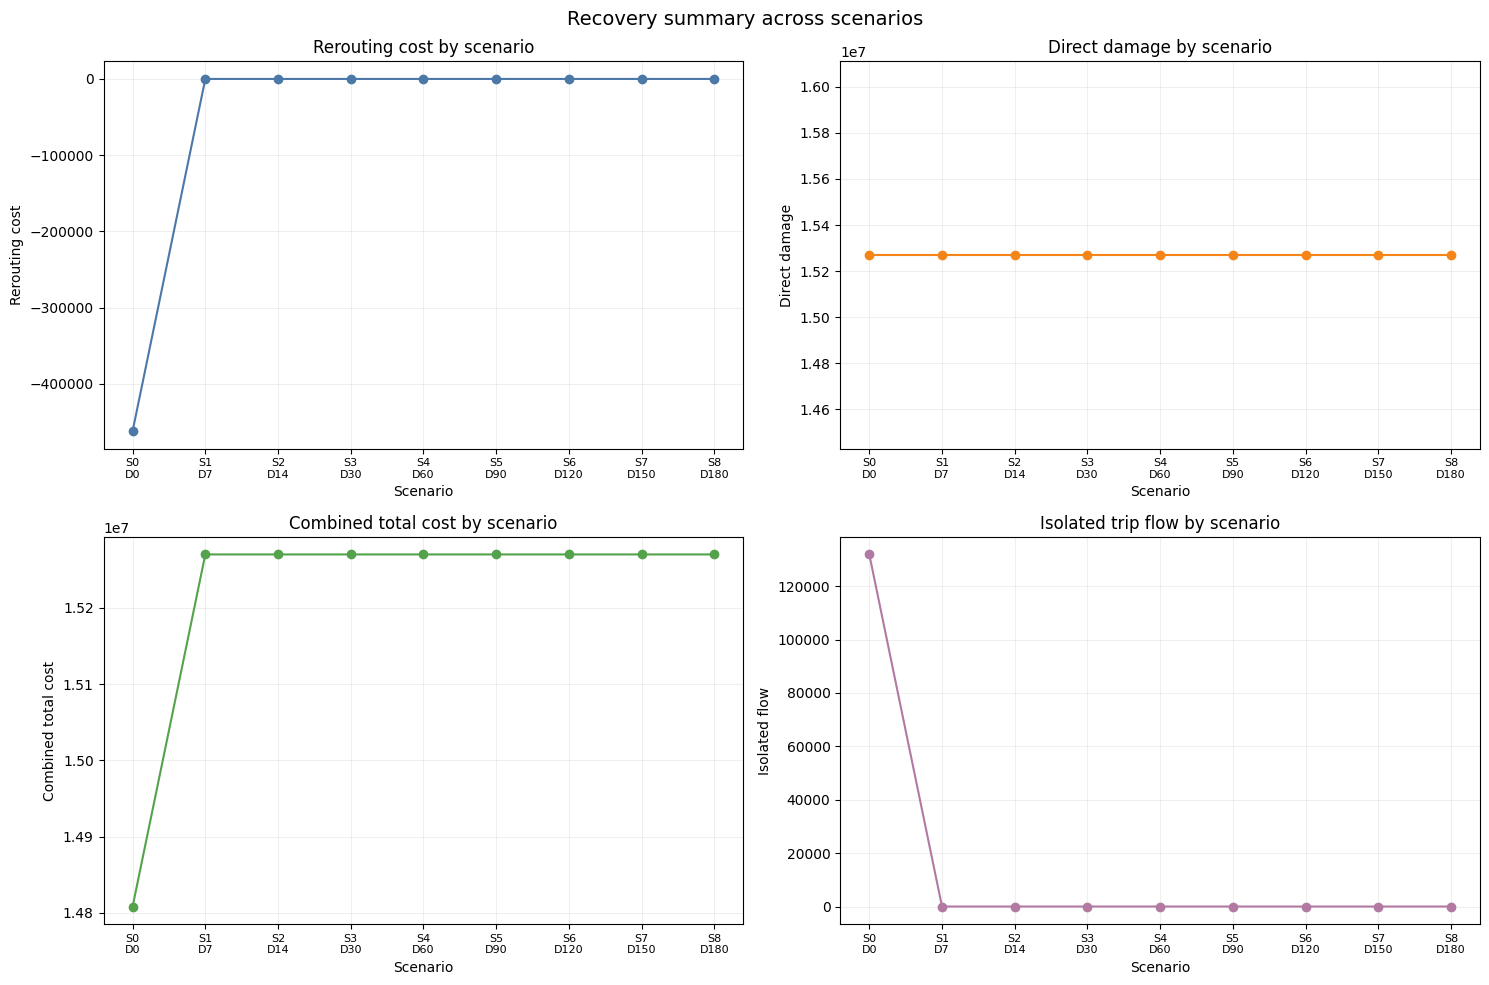

In [20]:
step4 = rerouting_costs.copy().sort_values("scenario")
scenario_days = {idx: day for idx, day in enumerate(RECOVERY_DAYS)}
step4["event_day"] = step4["scenario"].map(scenario_days)

trip_rows = []
trip_flows = []
for s in step4["scenario"].astype(int):
    pq_path = paths["rerouting_dir"] / f"trip_isolations_{s}.pq"
    csv_path = paths["rerouting_dir"] / f"trip_isolations_{s}.csv"
    p = pq_path if pq_path.exists() else csv_path
    if p.exists():
        df = pd.read_parquet(p) if p.suffix == ".pq" else pd.read_csv(p)
        fc = "flow" if "flow" in df.columns else ("Car21" if "Car21" in df.columns else None)
        trip_rows.append(len(df))
        trip_flows.append(float(df[fc].sum()) if fc else float(len(df)))
    else:
        trip_rows.append(np.nan)
        trip_flows.append(np.nan)

step4["isolated_trip_rows"] = trip_rows
step4["isolated_trip_flow"] = trip_flows

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
x = step4["scenario"].astype(int)

axes[0].plot(x, step4["rerouting_cost"], marker="o", color="#4c78a8")
axes[0].set_title("Rerouting cost by scenario")
axes[0].set_xlabel("Scenario")
axes[0].set_ylabel("Rerouting cost")
axes[0].grid(True, alpha=0.2)

axes[1].plot(x, step4["direct_damage_total"], marker="o", color="#f58518")
axes[1].set_title("Direct damage by scenario")
axes[1].set_xlabel("Scenario")
axes[1].set_ylabel("Direct damage")
axes[1].grid(True, alpha=0.2)

axes[2].plot(x, step4["combined_total_cost"], marker="o", color="#54a24b")
axes[2].set_title("Combined total cost by scenario")
axes[2].set_xlabel("Scenario")
axes[2].set_ylabel("Combined total cost")
axes[2].grid(True, alpha=0.2)

axes[3].plot(x, step4["isolated_trip_flow"], marker="o", color="#b279a2")
axes[3].set_title("Isolated trip flow by scenario")
axes[3].set_xlabel("Scenario")
axes[3].set_ylabel("Isolated flow")
axes[3].grid(True, alpha=0.2)

labels = [f"S{s}\nD{d}" for s, d in zip(step4["scenario"].astype(int), step4["event_day"].astype(int))]
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)

fig.suptitle("Recovery summary across scenarios", fontsize=14)
fig.tight_layout()
save_figure(fig, step4_fig_dir, "step4_recovery_summary")
plt.show()

### Step 4A. Cost assumptions and trip accounting context
This diagnostic panel helps interpret rerouting numbers:
- `rerouting_cost = rer_time + rer_operate + rer_toll` (all are deltas vs baseline)
- negative rerouting cost means net travel-cost savings relative to baseline
- isolated trip flow is taken from `trip_isolations_{scenario}` outputs
- isolated share is computed as `isolated_trip_flow / baseline_total_flow`

 scenario     rer_time  rer_operate  rer_toll  rerouting_cost  isolated_trip_rows  isolated_trip_flow  isolated_share_pct  direct_damage_total  combined_total_cost
        0 -305,083.909 -156,615.268     0.000    -461,699.176                 248         131,886.936              22.954       15,270,142.252       14,808,443.075
        1        0.000        0.000     0.000           0.000                   0               0.000               0.000       15,270,142.252       15,270,142.252
        2        0.000        0.000     0.000           0.000                   0               0.000               0.000       15,270,142.252       15,270,142.252
        3        0.000        0.000     0.000           0.000                   0               0.000               0.000       15,270,142.252       15,270,142.252
        4        0.000        0.000     0.000           0.000                   0               0.000               0.000       15,270,142.252       15,270,142.252
        5       

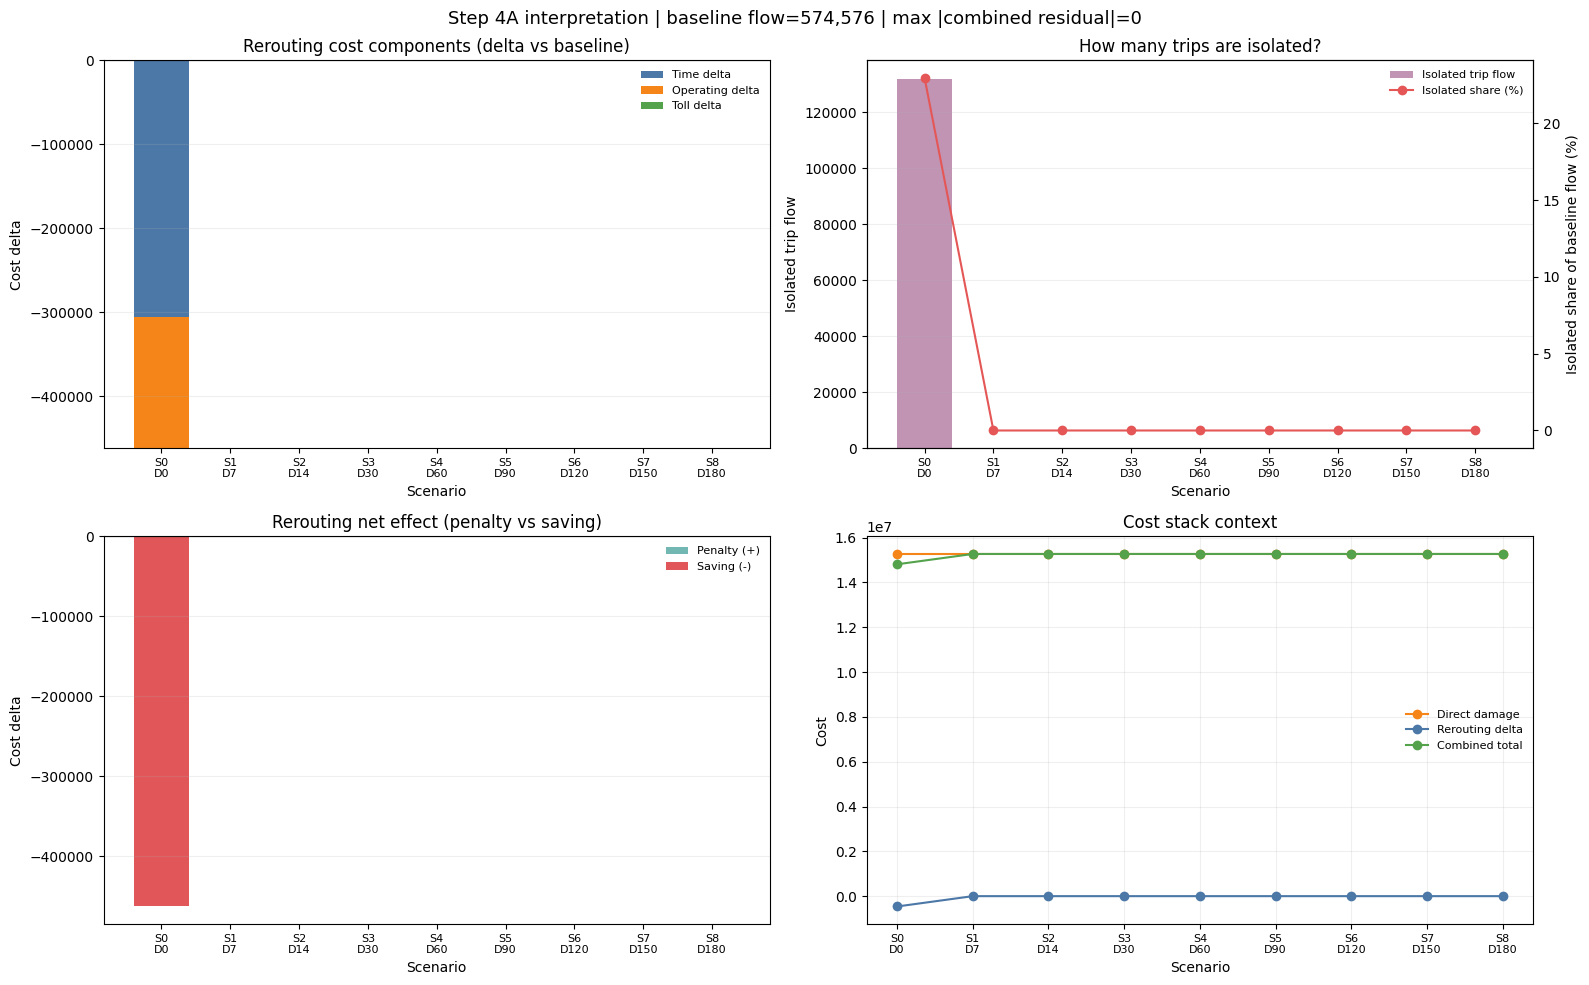

In [30]:
# Build an interpretation panel for rerouting economics and trip accounting
step4_diag = rerouting_costs.copy().sort_values("scenario").reset_index(drop=True)
step4_diag["scenario"] = step4_diag["scenario"].astype(int)

# Baseline flow denominator for isolation share
flow_col_diag = "flow" if "flow" in odpfc.columns else ("Car21" if "Car21" in odpfc.columns else None)
baseline_total_flow = float(odpfc[flow_col_diag].sum()) if flow_col_diag else np.nan

# Bring isolated trip rows/flow into this diagnostic dataframe
iso_rows = []
iso_flows = []
for s in step4_diag["scenario"]:
    pq_path = paths["rerouting_dir"] / f"trip_isolations_{s}.pq"
    csv_path = paths["rerouting_dir"] / f"trip_isolations_{s}.csv"
    p = pq_path if pq_path.exists() else csv_path
    if p.exists():
        iso_df = pd.read_parquet(p) if p.suffix == ".pq" else pd.read_csv(p)
        fc = "flow" if "flow" in iso_df.columns else ("Car21" if "Car21" in iso_df.columns else None)
        iso_rows.append(int(len(iso_df)))
        iso_flows.append(float(iso_df[fc].sum()) if fc else float(len(iso_df)))
    else:
        iso_rows.append(np.nan)
        iso_flows.append(np.nan)

step4_diag["isolated_trip_rows"] = iso_rows
step4_diag["isolated_trip_flow"] = iso_flows
step4_diag["isolated_share_pct"] = (step4_diag["isolated_trip_flow"] / baseline_total_flow * 100.0) if baseline_total_flow > 0 else np.nan

# Split rerouting into penalty (positive) vs savings (negative)
step4_diag["rerouting_penalty"] = step4_diag["rerouting_cost"].clip(lower=0)
step4_diag["rerouting_saving"] = step4_diag["rerouting_cost"].clip(upper=0)

# Consistency check: combined should equal direct + rerouting
step4_diag["combined_check"] = step4_diag["direct_damage_total"] + step4_diag["rerouting_cost"]
step4_diag["combined_residual"] = step4_diag["combined_total_cost"] - step4_diag["combined_check"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
x = step4_diag["scenario"].to_numpy()

# A) Rerouting components (delta vs baseline)
axes[0].bar(x, step4_diag["rer_time"], label="Time delta", color="#4c78a8")
axes[0].bar(x, step4_diag["rer_operate"], bottom=step4_diag["rer_time"], label="Operating delta", color="#f58518")
axes[0].bar(x, step4_diag["rer_toll"], bottom=step4_diag["rer_time"] + step4_diag["rer_operate"], label="Toll delta", color="#54a24b")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Rerouting cost components (delta vs baseline)")
axes[0].set_xlabel("Scenario")
axes[0].set_ylabel("Cost delta")
axes[0].legend(frameon=False, fontsize=8)
axes[0].grid(True, axis="y", alpha=0.2)

# B) Isolated trip accounting
axes[1].bar(x, step4_diag["isolated_trip_flow"], color="#b279a2", alpha=0.8, label="Isolated trip flow")
ax1b = axes[1].twinx()
ax1b.plot(x, step4_diag["isolated_share_pct"], color="#e45756", marker="o", label="Isolated share (%)")
axes[1].set_title("How many trips are isolated?")
axes[1].set_xlabel("Scenario")
axes[1].set_ylabel("Isolated trip flow")
ax1b.set_ylabel("Isolated share of baseline flow (%)")
axes[1].grid(True, axis="y", alpha=0.2)

# combined legend for twin axis
h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax1b.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, frameon=False, fontsize=8, loc="upper right")

# C) Rerouting penalty vs savings
axes[2].bar(x, step4_diag["rerouting_penalty"], color="#72b7b2", label="Penalty (+)")
axes[2].bar(x, step4_diag["rerouting_saving"], color="#e15759", label="Saving (-)")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Rerouting net effect (penalty vs saving)")
axes[2].set_xlabel("Scenario")
axes[2].set_ylabel("Cost delta")
axes[2].legend(frameon=False, fontsize=8)
axes[2].grid(True, axis="y", alpha=0.2)

# D) Direct vs rerouting vs combined
axes[3].plot(x, step4_diag["direct_damage_total"], marker="o", color="#f58518", label="Direct damage")
axes[3].plot(x, step4_diag["rerouting_cost"], marker="o", color="#4c78a8", label="Rerouting delta")
axes[3].plot(x, step4_diag["combined_total_cost"], marker="o", color="#54a24b", label="Combined total")
axes[3].set_title("Cost stack context")
axes[3].set_xlabel("Scenario")
axes[3].set_ylabel("Cost")
axes[3].legend(frameon=False, fontsize=8)
axes[3].grid(True, alpha=0.2)

labels = [f"S{s}\nD{d}" for s, d in zip(step4_diag["scenario"].astype(int), step4_diag["scenario"].map({idx: day for idx, day in enumerate(RECOVERY_DAYS)}).astype(int))]
for ax in [axes[0], axes[1], axes[2], axes[3]]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)

fig.suptitle(
    f"Step 4A interpretation | baseline flow={baseline_total_flow:,.0f} | max |combined residual|={step4_diag['combined_residual'].abs().max():.4g}",
    fontsize=13,
)
fig.tight_layout()
save_figure(fig, step4_fig_dir, "step4_interpretation_panel")

# Compact numeric table for quick review
display_cols = [
    "scenario",
    "rer_time",
    "rer_operate",
    "rer_toll",
    "rerouting_cost",
    "isolated_trip_rows",
    "isolated_trip_flow",
    "isolated_share_pct",
    "direct_damage_total",
    "combined_total_cost",
]
print(step4_diag[display_cols].to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

plt.show()

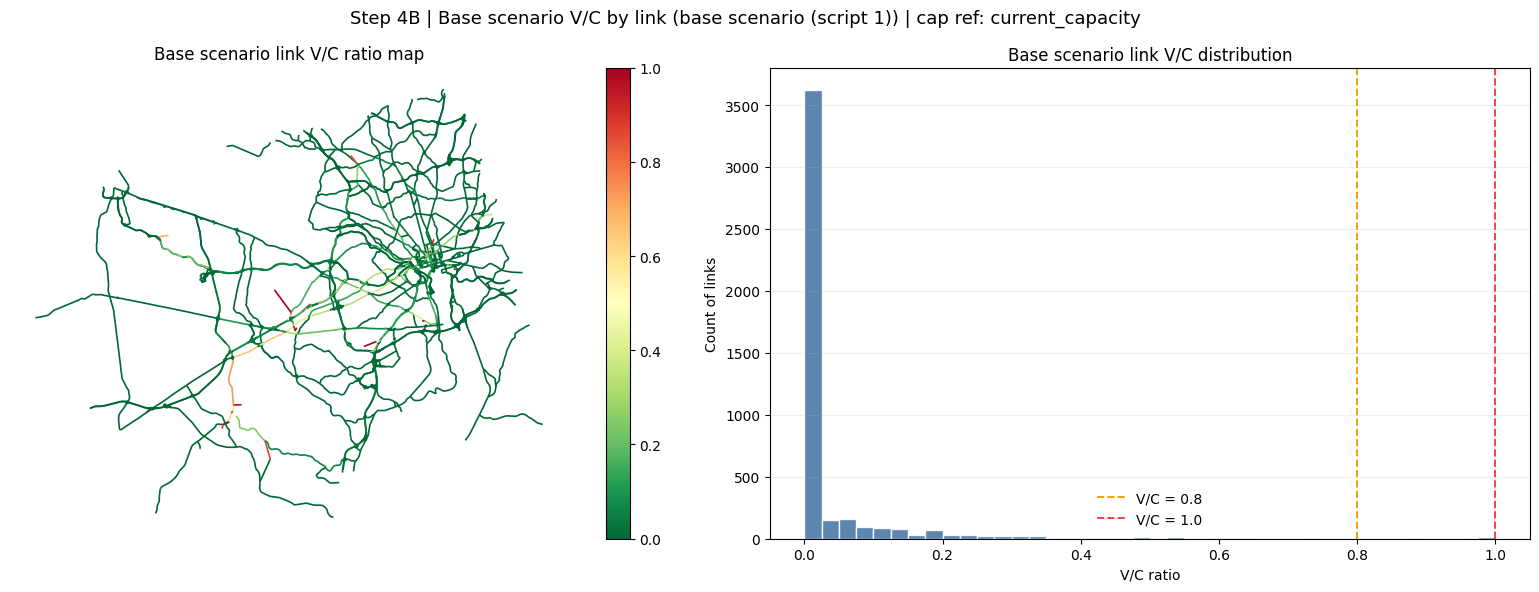

V/C source file: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\results\base_scenario\od_inflation_100x\edge_flows.gpq
Flow column used: acc_flow
Capacity reference: current_capacity
V/C summary: {'n_links': 4541, 'n_valid_vc': 4541, 'mean_vc': 0.0368677982673341, 'median_vc': 0.0, 'p95_vc': 0.21961947331914194, 'max_vc': 1.0000000000000002, 'over_capacity_share_pct': 0.022021581149526535}
Top 10 links by V/C:
   e_id   acc_flow  vc_ratio  current_capacity  acc_capacity  lanes
1656835 52,800.000     1.000             52800        -0.000      1
1647628 72,000.000     1.000             72000         0.000      2
1631517 72,000.000     1.000             72000         0.000      2
1646609 72,000.000     1.000             72000         0.000      2
1633284 52,800.000     1.000             52800        -0.000      1
1646644 52,800.000     1.000             52800         0.000      1
1635647 71,999.982     1.000             72000         0.018      2
1655327 71,997.642     1.000      

In [3]:
# Step 4B. Base-scenario link V/C (volume/capacity) visualization
# Uses base scenario edge flows from script 1 only.
# This cell is self-contained so it can run even after a kernel restart.

from pathlib import Path
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- bootstrap context if prior cells were not executed ----
if "VARIANT" not in globals():
    VARIANT = os.getenv("NIRD_RESULTS_VARIANT", "od_inflation_100x")
if "DEPTH_KEY" not in globals():
    DEPTH_KEY = 30
if "FLOOD_KEY" not in globals():
    FLOOD_KEY = 1

if "root" not in globals():
    root = Path.cwd()
    while root != root.parent and not (root / "pyproject.toml").exists():
        root = root.parent

if "results_root" not in globals():
    results_root = root / "sandbox" / "results"
if "fig_root" not in globals():
    fig_root = results_root / "figures" / VARIANT
if "step4_fig_dir" not in globals():
    step4_fig_dir = fig_root / "step4_rerouting"
step4_fig_dir.mkdir(parents=True, exist_ok=True)

if "save_figure" not in globals():
    def save_figure(fig: plt.Figure, out_dir: Path, stem: str) -> None:
        out_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_dir / f"{stem}.png", dpi=300, bbox_inches="tight", facecolor="white")
        fig.savefig(out_dir / f"{stem}.pdf", bbox_inches="tight", facecolor="white")

# ---- base scenario edge flows from script 1 ----
base_edge_path = results_root / "base_scenario" / VARIANT / "edge_flows.gpq"
if not base_edge_path.exists():
    raise FileNotFoundError(f"Missing base scenario edge flow file: {base_edge_path}")

final_edge_path = base_edge_path
final_edges = gpd.read_parquet(final_edge_path).copy()
source_label = "base scenario (script 1)"

if "e_id" in final_edges.columns:
    final_edges["e_id"] = final_edges["e_id"].astype(str)

# ---- pick flow column ----
if "acc_flow" in final_edges.columns:
    flow_col = "acc_flow"
elif "flow" in final_edges.columns:
    flow_col = "flow"
elif "current_flow" in final_edges.columns:
    flow_col = "current_flow"
else:
    raise ValueError("No usable flow column found. Expected one of: acc_flow, flow, current_flow")

# ---- build denominator (reference capacity) ----
if "current_capacity" in final_edges.columns:
    cap_ref = pd.to_numeric(final_edges["current_capacity"], errors="coerce")
    cap_source = "current_capacity"
elif {"acc_capacity", "acc_flow"}.issubset(final_edges.columns):
    # old-style outputs where acc_capacity is remaining capacity
    cap_ref = (
        pd.to_numeric(final_edges["acc_capacity"], errors="coerce")
        + pd.to_numeric(final_edges["acc_flow"], errors="coerce")
    )
    cap_source = "acc_flow + acc_capacity"
elif {"flow_capacity", "lanes"}.issubset(final_edges.columns):
    # heuristic fallback (often per-lane-per-hour)
    cap_ref = (
        pd.to_numeric(final_edges["flow_capacity"], errors="coerce")
        * pd.to_numeric(final_edges["lanes"], errors="coerce")
        * 24.0
    )
    cap_source = "flow_capacity * lanes * 24"
else:
    raise ValueError(
        "No usable capacity reference found. Expected current_capacity, "
        "or acc_capacity+acc_flow, or flow_capacity+lanes."
    )

flow_vals = pd.to_numeric(final_edges[flow_col], errors="coerce")
final_edges["vc_ratio"] = np.where(cap_ref > 0, flow_vals / cap_ref, np.nan)
final_edges["vc_ratio"] = pd.to_numeric(final_edges["vc_ratio"], errors="coerce")

# Basic diagnostics
valid_vc = final_edges["vc_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
if len(valid_vc) == 0:
    raise ValueError("V/C computation produced no valid values.")

final_edges["vc_class"] = pd.cut(
    final_edges["vc_ratio"],
    bins=[-np.inf, 0.8, 1.0, np.inf],
    labels=["under-capacity (<=0.8)", "near-capacity (0.8-1.0)", "over-capacity (>1.0)"],
)

# ---- plot: map + histogram ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: spatial V/C map
if "geometry" in final_edges.columns and final_edges.geometry.notna().any():
    plot_gdf = final_edges.copy()
    if plot_gdf.crs is None:
        plot_gdf = plot_gdf.set_crs("EPSG:4326")
    q99 = float(valid_vc.quantile(0.99))
    vmax = max(1.0, q99)
    plot_gdf.plot(
        ax=axes[0],
        column="vc_ratio",
        cmap="RdYlGn_r",
        linewidth=1.2,
        legend=True,
        vmin=0,
        vmax=vmax,
        missing_kwds={"color": "#d1d5db", "label": "No data"},
    )
    axes[0].set_title("Base scenario link V/C ratio map")
    axes[0].set_axis_off()
else:
    axes[0].text(0.5, 0.5, "No geometry available for map plot", ha="center", va="center")
    axes[0].set_axis_off()

# Right panel: distribution + threshold lines
axes[1].hist(valid_vc, bins=40, color="#4c78a8", edgecolor="white", alpha=0.9)
axes[1].axvline(0.8, color="#f59e0b", linestyle="--", linewidth=1.4, label="V/C = 0.8")
axes[1].axvline(1.0, color="#ef4444", linestyle="--", linewidth=1.4, label="V/C = 1.0")
axes[1].set_title("Base scenario link V/C distribution")
axes[1].set_xlabel("V/C ratio")
axes[1].set_ylabel("Count of links")
axes[1].grid(True, axis="y", alpha=0.2)
axes[1].legend(frameon=False)

fig.suptitle(
    f"Step 4B | Base scenario V/C by link ({source_label}) | cap ref: {cap_source}",
    fontsize=13,
)
fig.tight_layout()
save_figure(fig, step4_fig_dir, "step4_base_vc_ratio")
plt.show()

# ---- concise numeric summary ----
print(f"V/C source file: {final_edge_path}")
print(f"Flow column used: {flow_col}")
print(f"Capacity reference: {cap_source}")
print(
    "V/C summary:",
    {
        "n_links": int(len(final_edges)),
        "n_valid_vc": int(valid_vc.size),
        "mean_vc": float(valid_vc.mean()),
        "median_vc": float(valid_vc.median()),
        "p95_vc": float(valid_vc.quantile(0.95)),
        "max_vc": float(valid_vc.max()),
        "over_capacity_share_pct": float((valid_vc > 1.0).mean() * 100.0),
    },
)

if "e_id" in final_edges.columns:
    top_cols = ["e_id", flow_col, "vc_ratio"]
    extra_cols = [c for c in ["current_capacity", "acc_capacity", "lanes"] if c in final_edges.columns]
    top = (
        final_edges[top_cols + extra_cols]
        .copy()
        .sort_values("vc_ratio", ascending=False)
        .head(10)
    )
    print("Top 10 links by V/C:")
    print(top.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

## Step 0. Major model input tables and parameter diagnostics

This section visualizes key inputs used by damage and recovery workflows:

- `recovery design_updated.csv` (bridge/road recovery curves)
- `damage_ratio_road_flood_uk.xlsx` (damage ratio curves by flood intensity)
- `damage_cost_road_flood_uk.xlsx` (asset cost assumptions)
- parameter JSON files in `parameters/`

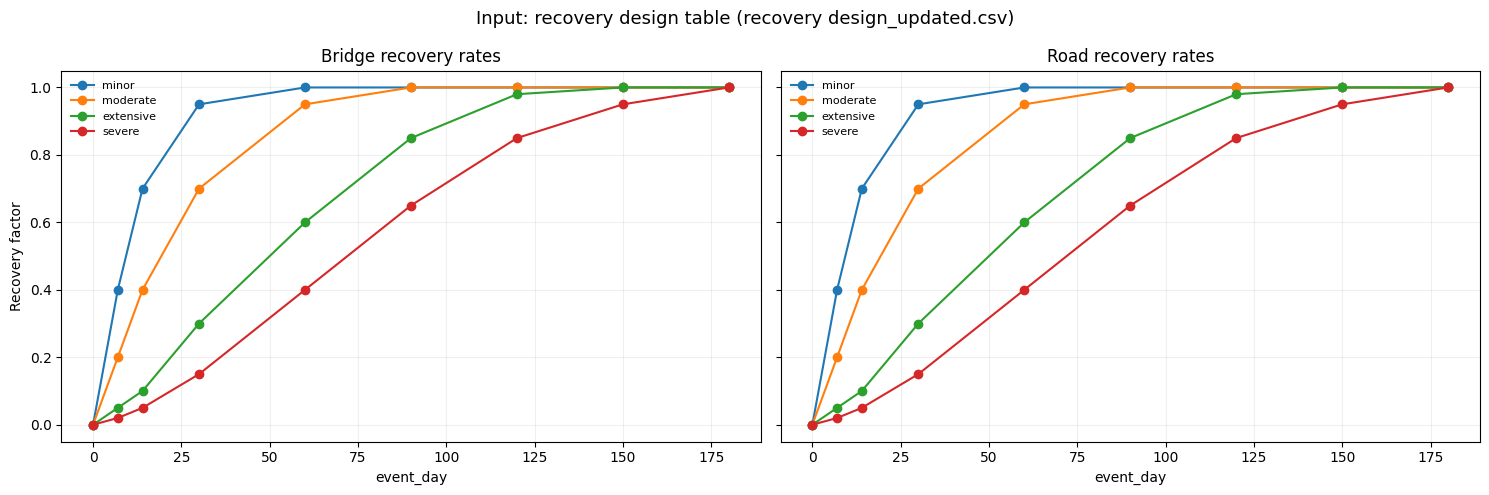

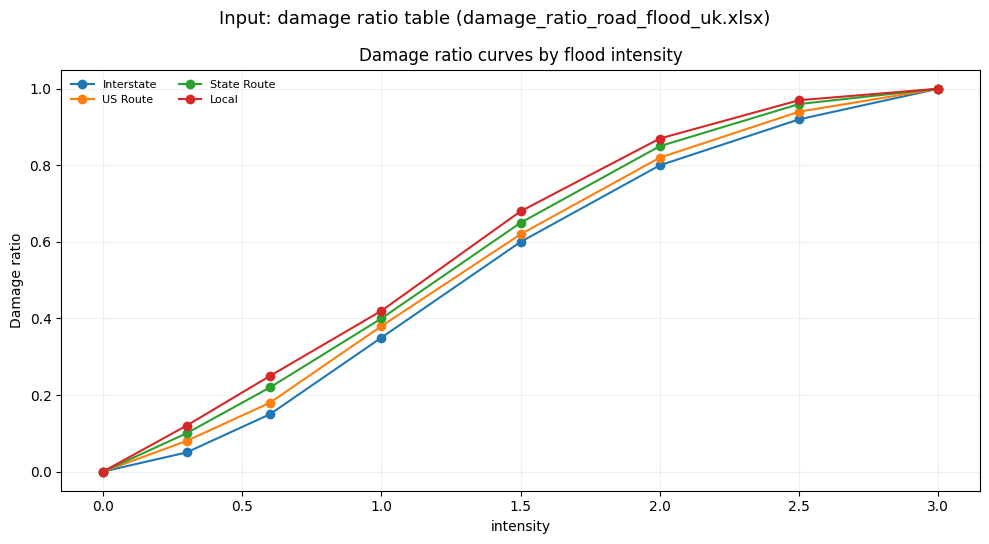

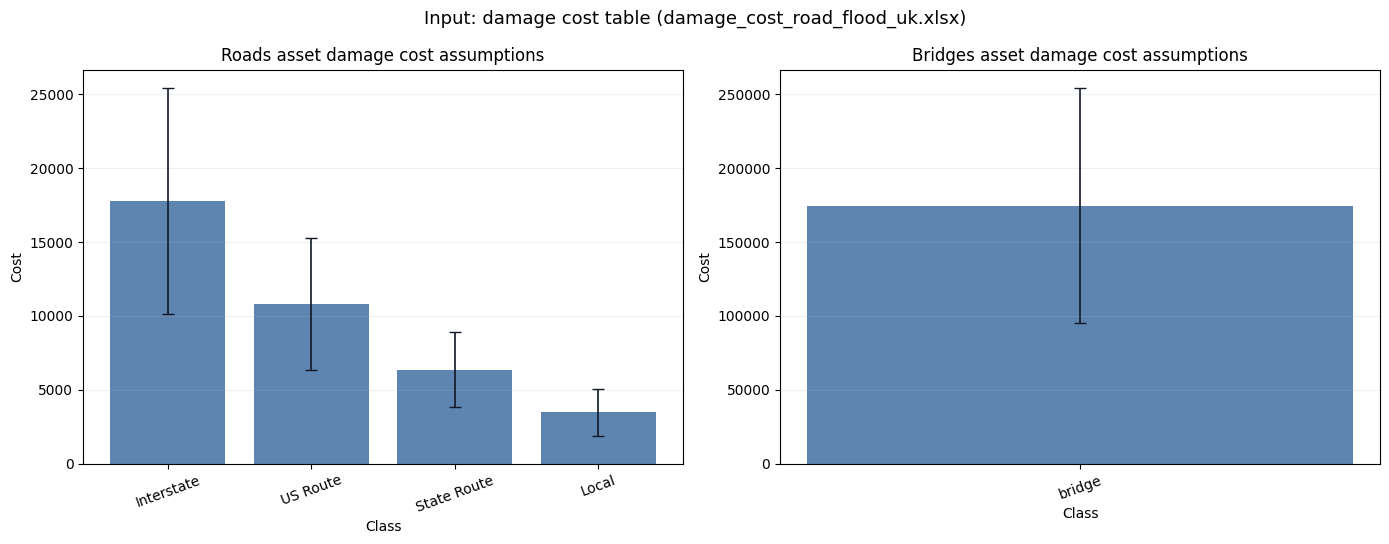

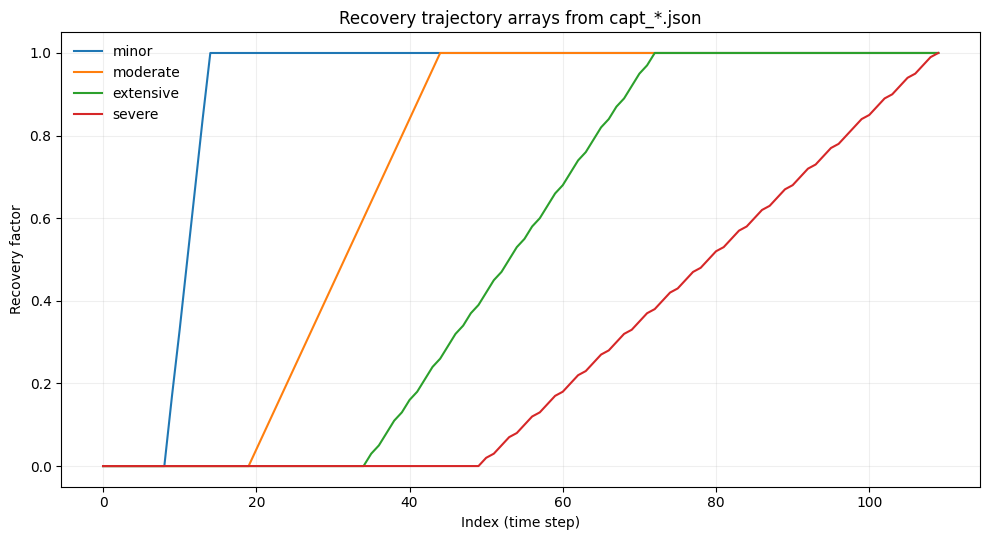

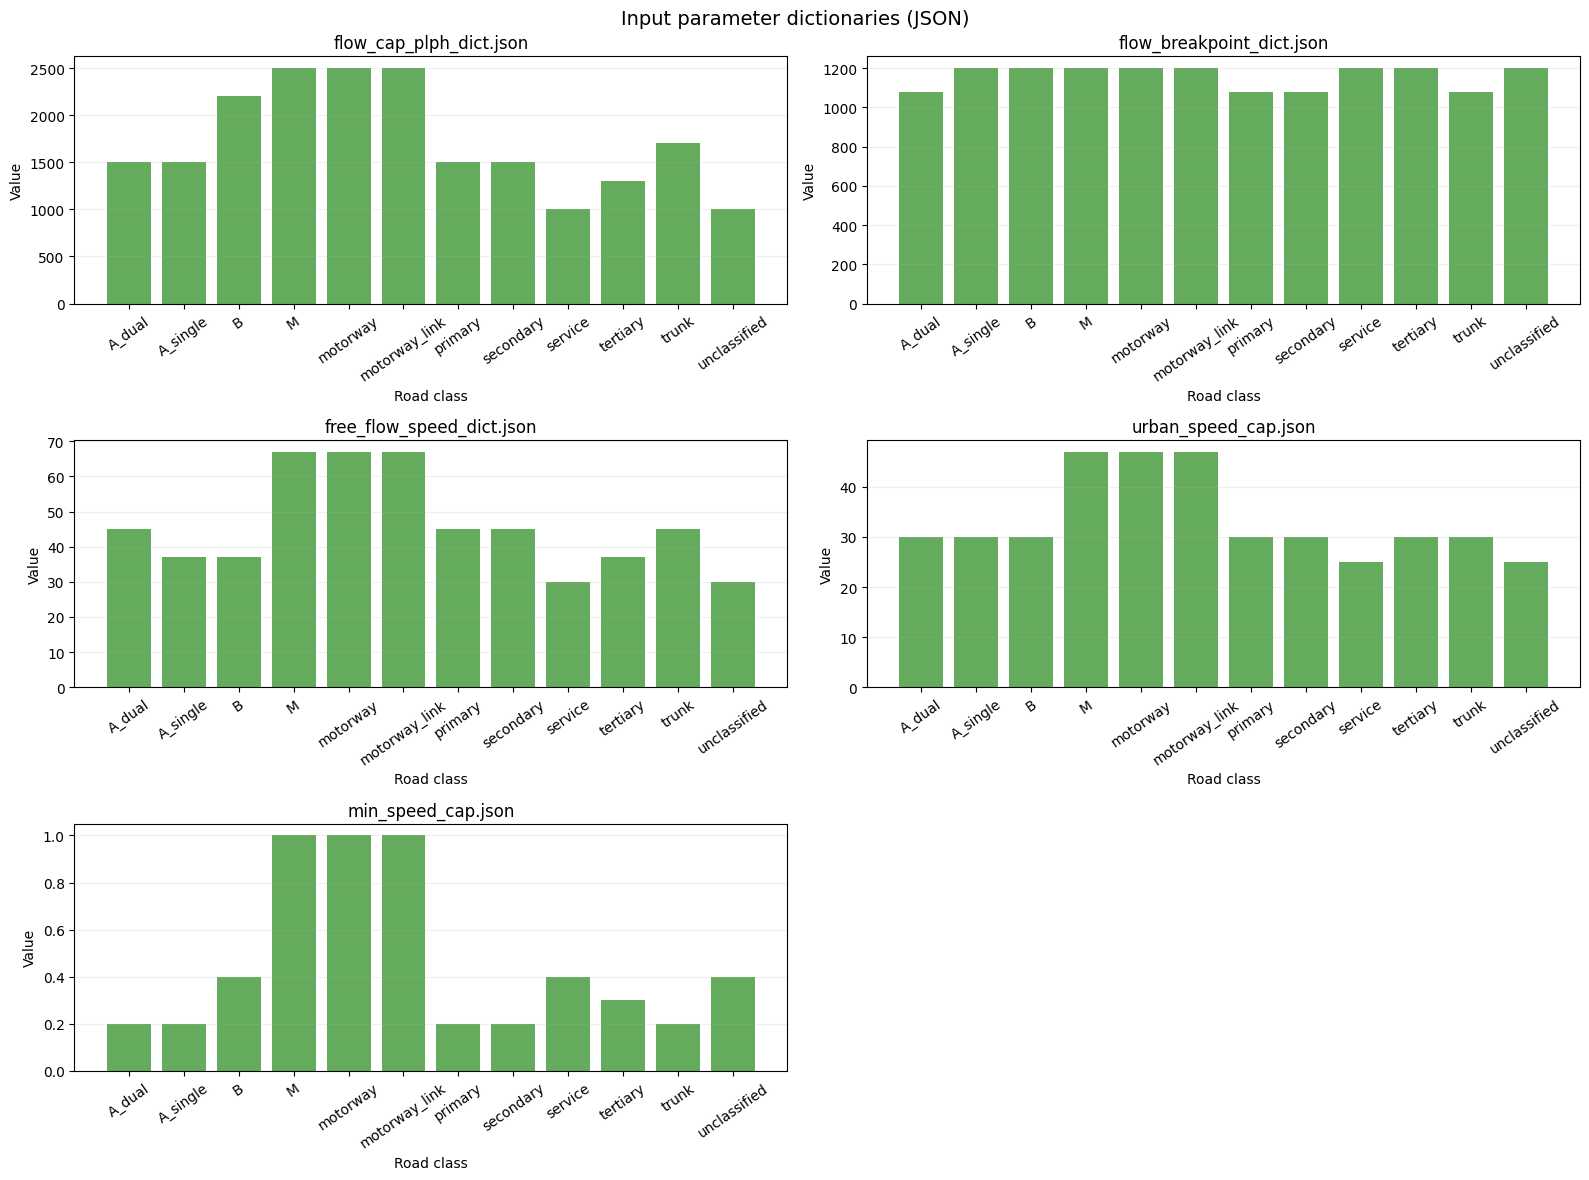

Parameter directory: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\fairfax_soge_clusters_toy\parameters
Detected JSON files:
 - capt_extensive.json
 - capt_minor.json
 - capt_moderate.json
 - capt_severe.json
 - flow_breakpoint_dict.json
 - flow_cap_plph_dict.json
 - free_flow_speed_dict.json
 - min_speed_cap.json
 - urban_speed_cap.json


In [4]:
# Visual diagnostics for major input tables and parameter JSONs

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- path discovery ----------
if "root" not in globals():
    root = Path.cwd()
    while root != root.parent and not (root / "pyproject.toml").exists():
        root = root.parent

candidate_bases = [
    root / "sandbox" / "fairfax_soge_clusters_toy",
    root / "sandbox" / "fairfax_baseline",
]
base_input = next((p for p in candidate_bases if p.exists()), None)
if base_input is None:
    raise FileNotFoundError("Could not find sandbox input base folder.")

step_inputs_fig_dir = fig_root / "step_inputs"
step_inputs_fig_dir.mkdir(parents=True, exist_ok=True)


def _first_existing(paths):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    return None


def _load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def _to_numeric_dict(d):
    out = {}
    for k, v in d.items():
        if str(k).startswith("_"):
            continue
        try:
            out[str(k)] = float(v)
        except Exception:
            continue
    return out


# ---------- 1) Recovery design table ----------
recovery_path = _first_existing([
    base_input / "tables" / "recovery design_updated.csv",
    base_input / "inputs" / "tables" / "recovery design_updated.csv",
])

if recovery_path is not None:
    recovery_df = pd.read_csv(recovery_path)

    bridge_cols = [c for c in recovery_df.columns if c.startswith("bridge_")]
    road_cols = [c for c in recovery_df.columns if c.startswith("road_")]

    x_col = "event_day" if "event_day" in recovery_df.columns else "scenario"

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    for c in bridge_cols:
        axes[0].plot(recovery_df[x_col], pd.to_numeric(recovery_df[c], errors="coerce"), marker="o", label=c.replace("bridge_", ""))
    axes[0].set_title("Bridge recovery rates")
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel("Recovery factor")
    axes[0].grid(True, alpha=0.2)
    axes[0].legend(frameon=False, fontsize=8)

    for c in road_cols:
        axes[1].plot(recovery_df[x_col], pd.to_numeric(recovery_df[c], errors="coerce"), marker="o", label=c.replace("road_", ""))
    axes[1].set_title("Road recovery rates")
    axes[1].set_xlabel(x_col)
    axes[1].grid(True, alpha=0.2)
    axes[1].legend(frameon=False, fontsize=8)

    fig.suptitle(f"Input: recovery design table ({recovery_path.name})", fontsize=13)
    fig.tight_layout()
    save_figure(fig, step_inputs_fig_dir, "inputs_recovery_design")
    plt.show()
else:
    print("Recovery table not found.")


# ---------- 2) Damage ratio curve table ----------
ratio_path = _first_existing([
    base_input / "damage_curves" / "damage_ratio_road_flood_uk.xlsx",
    base_input / "damage_curves" / "damage_ratio_road_flood.xlsx",
    base_input / "tables" / "damage_ratio_road_flood_uk.xlsx",
    base_input / "tables" / "damage_ratio_road_flood.xlsx",
    base_input / "inputs" / "lookup" / "damage_ratio_road_flood_uk.xlsx",
    base_input / "inputs" / "lookup" / "damage_ratio_road_flood.xlsx",
    base_input / "damage_curves" / "damage_ratio_road_flood_uk.csv",
    base_input / "damage_curves" / "damage_ratio_road_flood.csv",
])

if ratio_path is not None:
    if ratio_path.suffix.lower() == ".xlsx":
        ratio_df = pd.read_excel(ratio_path, sheet_name=0)
    else:
        ratio_df = pd.read_csv(ratio_path)

    ratio_df = ratio_df.copy()
    ratio_df.columns = [str(c).strip() for c in ratio_df.columns]
    x_col = "intensity" if "intensity" in ratio_df.columns else ratio_df.columns[0]

    fig, ax = plt.subplots(figsize=(10, 5.5))
    for c in ratio_df.columns:
        if c == x_col:
            continue
        y = pd.to_numeric(ratio_df[c], errors="coerce")
        if y.notna().sum() == 0:
            continue
        ax.plot(pd.to_numeric(ratio_df[x_col], errors="coerce"), y, marker="o", label=c)

    ax.set_title("Damage ratio curves by flood intensity")
    ax.set_xlabel(x_col)
    ax.set_ylabel("Damage ratio")
    ax.grid(True, alpha=0.2)
    ax.legend(frameon=False, fontsize=8, ncol=2)
    fig.suptitle(f"Input: damage ratio table ({ratio_path.name})", fontsize=13)
    fig.tight_layout()
    save_figure(fig, step_inputs_fig_dir, "inputs_damage_ratio_curves")
    plt.show()
else:
    print("Damage ratio table not found.")


# ---------- 3) Damage cost table ----------
cost_path = _first_existing([
    base_input / "asset_costs" / "damage_cost_road_flood_uk.xlsx",
    base_input / "tables" / "damage_cost_road_flood_uk.xlsx",
    base_input / "inputs" / "lookup" / "damage_cost_road_flood_uk.xlsx",
    base_input / "asset_costs" / "damage_cost_road_flood_uk.csv",
])

if cost_path is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    if cost_path.suffix.lower() == ".xlsx":
        xls = pd.ExcelFile(cost_path)
        sheet_names = xls.sheet_names

        for ax_idx, sh in enumerate(sheet_names[:2]):
            d = pd.read_excel(cost_path, sheet_name=sh)
            d.columns = [str(c).strip() for c in d.columns]
            if not {"label", "Min", "Max", "Mean"}.issubset(d.columns):
                axes[ax_idx].text(0.5, 0.5, f"Unsupported columns in sheet '{sh}'", ha="center", va="center")
                axes[ax_idx].set_axis_off()
                continue

            dd = d.copy()
            dd["label"] = dd["label"].astype(str)
            dd["Min"] = pd.to_numeric(dd["Min"], errors="coerce")
            dd["Max"] = pd.to_numeric(dd["Max"], errors="coerce")
            dd["Mean"] = pd.to_numeric(dd["Mean"], errors="coerce")

            yerr_lower = (dd["Mean"] - dd["Min"]).clip(lower=0).to_numpy()
            yerr_upper = (dd["Max"] - dd["Mean"]).clip(lower=0).to_numpy()

            axes[ax_idx].bar(dd["label"], dd["Mean"], color="#4c78a8", alpha=0.9)
            axes[ax_idx].errorbar(
                dd["label"],
                dd["Mean"],
                yerr=np.vstack([yerr_lower, yerr_upper]),
                fmt="none",
                ecolor="#111827",
                elinewidth=1.2,
                capsize=4,
            )
            axes[ax_idx].set_title(f"{sh.capitalize()} asset damage cost assumptions")
            axes[ax_idx].set_xlabel("Class")
            axes[ax_idx].set_ylabel("Cost")
            axes[ax_idx].grid(True, axis="y", alpha=0.2)
            axes[ax_idx].tick_params(axis="x", rotation=20)
    else:
        d = pd.read_csv(cost_path)
        d.columns = [str(c).strip() for c in d.columns]
        if {"label", "Min", "Max", "Mean"}.issubset(d.columns):
            dd = d.copy()
            dd["label"] = dd["label"].astype(str)
            dd["Min"] = pd.to_numeric(dd["Min"], errors="coerce")
            dd["Max"] = pd.to_numeric(dd["Max"], errors="coerce")
            dd["Mean"] = pd.to_numeric(dd["Mean"], errors="coerce")
            yerr_lower = (dd["Mean"] - dd["Min"]).clip(lower=0).to_numpy()
            yerr_upper = (dd["Max"] - dd["Mean"]).clip(lower=0).to_numpy()
            axes[0].bar(dd["label"], dd["Mean"], color="#4c78a8", alpha=0.9)
            axes[0].errorbar(
                dd["label"], dd["Mean"], yerr=np.vstack([yerr_lower, yerr_upper]),
                fmt="none", ecolor="#111827", elinewidth=1.2, capsize=4
            )
            axes[0].set_title("Asset damage cost assumptions")
            axes[0].set_xlabel("Class")
            axes[0].set_ylabel("Cost")
            axes[0].grid(True, axis="y", alpha=0.2)
            axes[0].tick_params(axis="x", rotation=20)
            axes[1].set_axis_off()
        else:
            for ax in axes:
                ax.text(0.5, 0.5, "Unsupported damage-cost CSV format", ha="center", va="center")
                ax.set_axis_off()

    fig.suptitle(f"Input: damage cost table ({cost_path.name})", fontsize=13)
    fig.tight_layout()
    save_figure(fig, step_inputs_fig_dir, "inputs_damage_cost_assumptions")
    plt.show()
else:
    print("Damage cost table not found.")


# ---------- 4) Parameter JSONs ----------
param_dir = _first_existing([
    base_input / "parameters",
    base_input / "inputs" / "parameters",
])

if param_dir is not None:
    json_paths = sorted(param_dir.glob("*.json"))

    # 4A) Captured capacity trajectories
    cap_files = [
        "capt_minor.json",
        "capt_moderate.json",
        "capt_extensive.json",
        "capt_severe.json",
    ]
    cap_series = {}
    for fn in cap_files:
        p = param_dir / fn
        if p.exists():
            obj = _load_json(p)
            if isinstance(obj, list):
                cap_series[fn.replace("capt_", "").replace(".json", "")] = pd.to_numeric(pd.Series(obj), errors="coerce")

    if cap_series:
        fig, ax = plt.subplots(figsize=(10, 5.5))
        for name, s in cap_series.items():
            ax.plot(np.arange(len(s)), s, label=name)
        ax.set_title("Recovery trajectory arrays from capt_*.json")
        ax.set_xlabel("Index (time step)")
        ax.set_ylabel("Recovery factor")
        ax.grid(True, alpha=0.2)
        ax.legend(frameon=False)
        fig.tight_layout()
        save_figure(fig, step_inputs_fig_dir, "inputs_parameters_capt_series")
        plt.show()

    # 4B) Dictionary-based parameter comparison
    dict_files = [
        "flow_cap_plph_dict.json",
        "flow_breakpoint_dict.json",
        "free_flow_speed_dict.json",
        "urban_speed_cap.json",
        "min_speed_cap.json",
    ]

    rows = []
    for fn in dict_files:
        p = param_dir / fn
        if not p.exists():
            continue
        obj = _load_json(p)
        if not isinstance(obj, dict):
            continue
        dd = _to_numeric_dict(obj)
        for k, v in dd.items():
            rows.append({"file": fn, "class": k, "value": v})

    if rows:
        param_df = pd.DataFrame(rows)

        fig, axes = plt.subplots(3, 2, figsize=(16, 12))
        axes = axes.flatten()

        for i, fn in enumerate([f for f in dict_files if (param_dir / f).exists()]):
            if i >= len(axes):
                break
            ax = axes[i]
            d = param_df[param_df["file"] == fn].copy().sort_values("class")
            ax.bar(d["class"], d["value"], color="#54a24b", alpha=0.9)
            ax.set_title(fn)
            ax.set_xlabel("Road class")
            ax.set_ylabel("Value")
            ax.grid(True, axis="y", alpha=0.2)
            ax.tick_params(axis="x", rotation=35)

        for j in range(i + 1, len(axes)):
            axes[j].set_axis_off()

        fig.suptitle("Input parameter dictionaries (JSON)", fontsize=14)
        fig.tight_layout()
        save_figure(fig, step_inputs_fig_dir, "inputs_parameters_dicts")
        plt.show()

    print(f"Parameter directory: {param_dir}")
    print("Detected JSON files:")
    for p in json_paths:
        print(" -", p.name)
else:
    print("Parameter directory not found.")

## Optional future hazard map overlay

Use this section later when you want raster hazard layers and exposed assets on one map.
It follows your preferred style with log scaled flood depth and custom colormap.

In [ ]:
# Optional: only run this when raster and map dependencies are installed and data paths are set.
#
# from matplotlib.lines import Line2D
# import matplotlib.colors as mcolors
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# import rasterio
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# from rasterio.enums import Resampling
# from rasterio.warp import transform_bounds
#
# EXTENT = [-120, -75, 23, 50]
# flood_cmap = mcolors.LinearSegmentedColormap.from_list(
#     "flood_purple", ["#deebf7","#dadaeb","#9e9ac8","#6a51a3","#3f007d"], N=256
# )
# flood_cmap.set_bad(alpha=0)
# flood_norm = mcolors.LogNorm(vmin=0.1, vmax=30)
#
# Fill in your hazard and exposure paths, then adapt from your existing map code.
print("Hazard map section is ready to customize when hazard layers are available.")

## Step 5. Export current figures + 100x (2x flood) visualization bundle

This section does **not** run pipeline scripts.
It only reads existing outputs and saves:
- a copy/export bundle of currently generated notebook figures
- comparison visuals for available flood scenarios under `od_inflation_100x` (expected: baseline/low/high IDs such as 1/2/3).

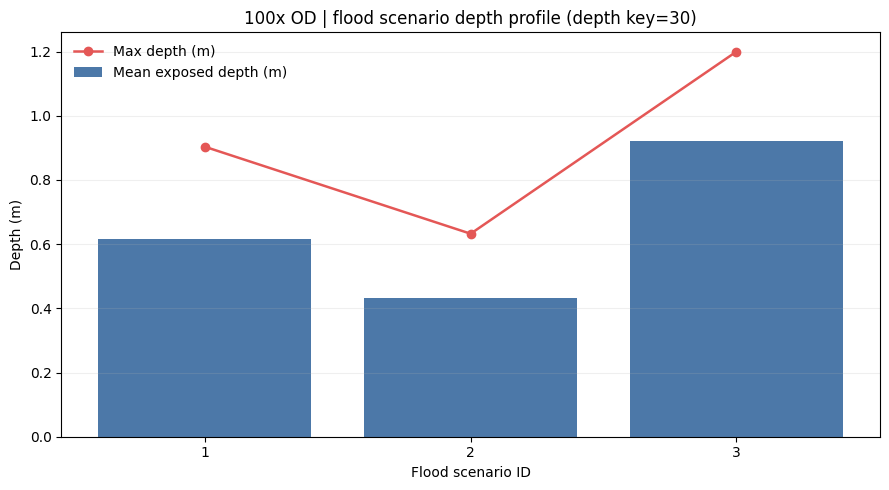

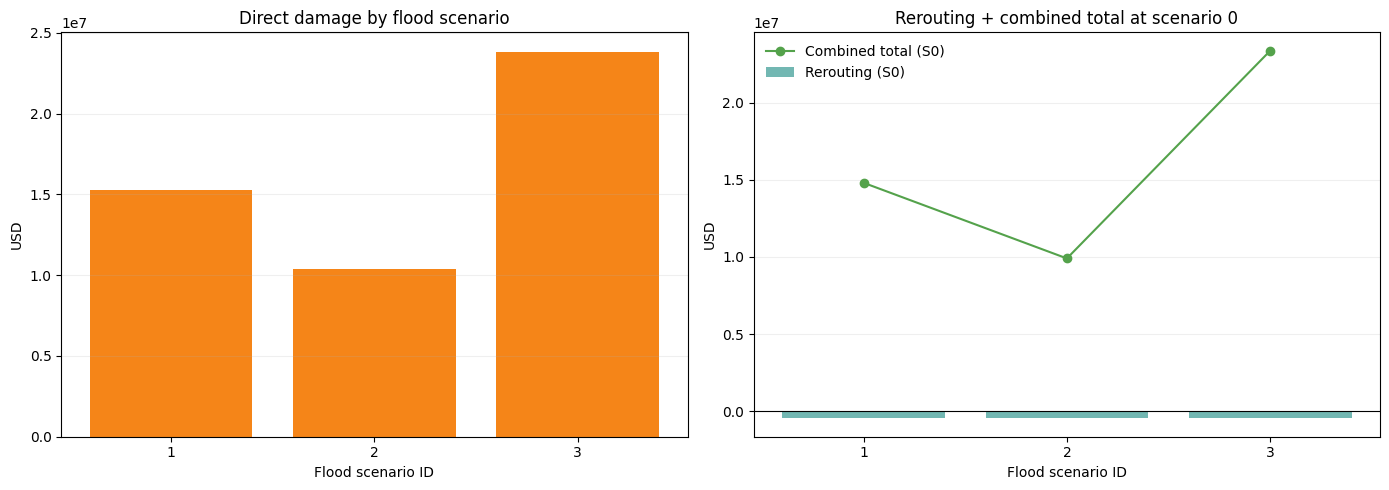

Copied existing figure files: 16
Current visualization bundle: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\results\figures\od_inflation_100x\exports\100x_current_visualization
2x flood comparison bundle: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\results\figures\od_inflation_100x\exports\100x_2x_flood
Summary table: c:\Users\alimu\Desktop\Github\DAFNI-NIRD-clean\sandbox\results\figures\od_inflation_100x\exports\100x_2x_flood\summary_100x_2x_flood.csv
Detected flood IDs: [1, 2, 3]
 flood_id  n_links  exposed_links  mean_depth_m  max_depth_m  direct_damage_usd  rerouting_cost_s0  combined_total_s0
        1     4541           3092         0.616        0.904     15,270,142.252       -461,699.176     14,808,443.075
        2     4541           3092         0.431        0.632     10,366,689.901       -461,699.176      9,904,990.724
        3     4541           3092         0.923        1.200     23,833,265.497       -461,699.176     23,371,566.321


In [39]:
import shutil

export_root = fig_root / "exports"
current_bundle_dir = export_root / "100x_current_visualization"
comparison_bundle_dir = export_root / "100x_2x_flood"
current_bundle_dir.mkdir(parents=True, exist_ok=True)
comparison_bundle_dir.mkdir(parents=True, exist_ok=True)


def _copy_existing_figures(src_dir: Path, dst_dir: Path) -> int:
    dst_dir.mkdir(parents=True, exist_ok=True)
    copied = 0
    if not src_dir.exists():
        return copied
    for ext in ("*.png", "*.pdf"):
        for f in src_dir.glob(ext):
            shutil.copy2(f, dst_dir / f.name)
            copied += 1
    return copied


copied_total = 0
copied_total += _copy_existing_figures(step1_fig_dir, current_bundle_dir / "step1_base")
copied_total += _copy_existing_figures(step2_fig_dir, current_bundle_dir / "step2_disruption")
copied_total += _copy_existing_figures(step3_fig_dir, current_bundle_dir / "step3_damage")
copied_total += _copy_existing_figures(step4_fig_dir, current_bundle_dir / "step4_rerouting")

links_dir = results_root / "disruption_analysis" / VARIANT / str(DEPTH_KEY) / "links"
flood_ids = []
if links_dir.exists():
    for p in links_dir.glob("road_links_*.gpq"):
        tail = p.stem.split("_")[-1]
        if tail.isdigit():
            flood_ids.append(int(tail))
flood_ids = sorted(set(flood_ids))

rows = []
for fid in flood_ids:
    links_path = results_root / "disruption_analysis" / VARIANT / str(DEPTH_KEY) / "links" / f"road_links_{fid}.gpq"
    dmg_path = results_root / "damage_analysis" / VARIANT / f"intersections_{fid}_with_damage_values.csv"
    rer_path = results_root / "rerouting_analysis" / VARIANT / str(DEPTH_KEY) / str(fid) / "cost_matrix_by_scenario.csv"

    if not links_path.exists():
        continue

    links = gpd.read_parquet(links_path)
    flood_col_local = "flood_depth_max" if "flood_depth_max" in links.columns else next((c for c in links.columns if c.startswith("flood_depth")), None)
    depth_vals = pd.to_numeric(links[flood_col_local], errors="coerce") if flood_col_local else pd.Series(np.nan, index=links.index)
    exposed = depth_vals.fillna(0) > 0

    total_damage = np.nan
    if dmg_path.exists():
        dmg = pd.read_csv(dmg_path)
        dmg_cols = [c for c in dmg.columns if c.endswith("_damage_value_mean")]
        if dmg_cols:
            total_damage = float(dmg[dmg_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1, min_count=1).sum(skipna=True))

    rerouting_s0 = np.nan
    combined_s0 = np.nan
    if rer_path.exists():
        rer = pd.read_csv(rer_path)
        if "scenario" in rer.columns:
            rer0 = rer.loc[pd.to_numeric(rer["scenario"], errors="coerce") == 0]
            if len(rer0) > 0:
                rerouting_s0 = float(pd.to_numeric(rer0.iloc[0].get("rerouting_cost", np.nan), errors="coerce"))
                combined_s0 = float(pd.to_numeric(rer0.iloc[0].get("combined_total_cost", np.nan), errors="coerce"))

    rows.append({
        "flood_id": fid,
        "n_links": int(len(links)),
        "exposed_links": int(exposed.sum()),
        "mean_depth_m": float(depth_vals[exposed].mean()) if int(exposed.sum()) > 0 else 0.0,
        "max_depth_m": float(depth_vals.max()) if depth_vals.notna().any() else 0.0,
        "direct_damage_usd": total_damage,
        "rerouting_cost_s0": rerouting_s0,
        "combined_total_s0": combined_s0,
    })

summary_2x = pd.DataFrame(rows).sort_values("flood_id").reset_index(drop=True)
summary_csv = comparison_bundle_dir / "summary_100x_2x_flood.csv"
summary_2x.to_csv(summary_csv, index=False)

# Figure A: depth profile comparison
if len(summary_2x) > 0:
    fig_a, ax_a = plt.subplots(figsize=(9, 5))
    x = summary_2x["flood_id"].astype(int).astype(str)
    ax_a.bar(x, summary_2x["mean_depth_m"], label="Mean exposed depth (m)", color="#4c78a8")
    ax_a.plot(x, summary_2x["max_depth_m"], marker="o", color="#e45756", linewidth=1.8, label="Max depth (m)")
    ax_a.set_title(f"100x OD | flood scenario depth profile (depth key={DEPTH_KEY})")
    ax_a.set_xlabel("Flood scenario ID")
    ax_a.set_ylabel("Depth (m)")
    ax_a.grid(True, axis="y", alpha=0.2)
    ax_a.legend(frameon=False)
    fig_a.tight_layout()
    save_figure(fig_a, comparison_bundle_dir, "depth_profile_100x_2x_flood")
    plt.show()

    # Figure B: cost comparison (direct + rerouting at scenario 0)
    fig_b, axes_b = plt.subplots(1, 2, figsize=(14, 5))

    axes_b[0].bar(x, summary_2x["direct_damage_usd"].fillna(0.0), color="#f58518")
    axes_b[0].set_title("Direct damage by flood scenario")
    axes_b[0].set_xlabel("Flood scenario ID")
    axes_b[0].set_ylabel("USD")
    axes_b[0].grid(True, axis="y", alpha=0.2)

    axes_b[1].bar(x, summary_2x["rerouting_cost_s0"].fillna(0.0), color="#72b7b2", label="Rerouting (S0)")
    axes_b[1].plot(x, summary_2x["combined_total_s0"].fillna(0.0), marker="o", color="#54a24b", label="Combined total (S0)")
    axes_b[1].axhline(0, color="black", linewidth=0.8)
    axes_b[1].set_title("Rerouting + combined total at scenario 0")
    axes_b[1].set_xlabel("Flood scenario ID")
    axes_b[1].set_ylabel("USD")
    axes_b[1].grid(True, axis="y", alpha=0.2)
    axes_b[1].legend(frameon=False)

    fig_b.tight_layout()
    save_figure(fig_b, comparison_bundle_dir, "cost_profile_100x_2x_flood")
    plt.show()

print(f"Copied existing figure files: {copied_total}")
print(f"Current visualization bundle: {current_bundle_dir}")
print(f"2x flood comparison bundle: {comparison_bundle_dir}")
print(f"Summary table: {summary_csv}")
print("Detected flood IDs:", flood_ids)
if len(summary_2x) > 0:
    print(summary_2x.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))
else:
    print("No flood scenario files were detected under disruption links for this variant.")

In [ ]:
# Consolidate ALL visualization pipeline plots into the 100x_2x_flood bundle
bundle_dir = fig_root / "exports" / "100x_2x_flood"
bundle_dir.mkdir(parents=True, exist_ok=True)

sources = {
    "step1_base": step1_fig_dir,
    "step2_disruption": step2_fig_dir,
    "step3_damage": step3_fig_dir,
    "step4_rerouting": step4_fig_dir,
}

copied_rows = []
total_copied = 0
for label, src in sources.items():
    dst = bundle_dir / label
    dst.mkdir(parents=True, exist_ok=True)
    if not src.exists():
        continue
    for ext in ("*.png", "*.pdf"):
        for f in src.glob(ext):
            out = dst / f.name
            shutil.copy2(f, out)
            copied_rows.append({
                "group": label,
                "source_path": str(f),
                "bundle_path": str(out),
                "ext": f.suffix.lower(),
            })
            total_copied += 1

# Also keep Step 5 comparison plots in root of 100x_2x_flood for convenience
for stem in ["depth_profile_100x_2x_flood", "cost_profile_100x_2x_flood"]:
    for ext in [".png", ".pdf"]:
        p = bundle_dir / f"{stem}{ext}"
        if p.exists():
            copied_rows.append({
                "group": "step5_comparison",
                "source_path": str(p),
                "bundle_path": str(p),
                "ext": ext,
            })

manifest = pd.DataFrame(copied_rows)
manifest_path = bundle_dir / "figure_manifest_100x_2x_flood.csv"
manifest.to_csv(manifest_path, index=False)

print(f"100x_2x_flood bundle path: {bundle_dir}")
print(f"Pipeline plots copied into bundle subfolders: {total_copied}")
print(f"Manifest: {manifest_path}")
if len(manifest) > 0:
    print(manifest.groupby("group").size().to_string())
else:
    print("No figures were found to bundle.")

NameError: name 'fig_root' is not defined

: 

### Step 2A. Flood disruption scenario comparison (baseline, low, high)
This panel uses **risk-oriented metrics** that are easier to interpret:
- **Exposed length (km)**: total road length with flood depth > 0
- **Flow at risk (vehicles/day)**: baseline `acc_flow` allocated to exposed links via `e_id` join
- **Deep-flood share (%)**: percent of exposed links with depth > 0.5 m

Scenario sourcing logic remains the same:
- `baseline`: synthetic no-flood reference
- `low`: lowest available flood scenario ID
- `high`: highest distinct available flood scenario ID (fallback to `revision` variant if needed)

Flood disruption scenario summary (risk metrics)
scenario_label  scenario_id    source_variant             status  exposed_links  exposed_length_km   flow_at_risk  mean_exposed_depth_m  deep_flood_share_pct
      baseline           -1 od_inflation_100x synthetic_baseline              0              0.000          0.000                 0.000                 0.000
           low            1 od_inflation_100x                 ok           3092          1,857.575 16,743,419.110                 0.616                77.426
          high            3          revision                 ok           3092          1,857.575 16,743,419.110                 0.923                92.529


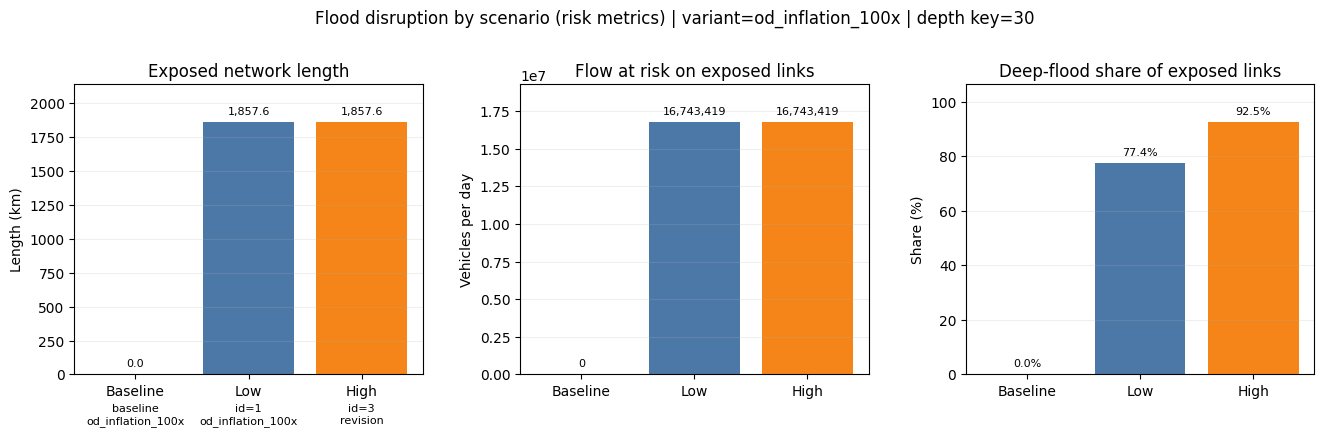

In [ ]:
# Scenario comparison for flood disruption context (risk-oriented metrics)
# Always show Baseline / Low / High as three bars.

PRIMARY_VARIANT = VARIANT
FALLBACK_VARIANT = "revision"  # script-2 outputs often exist here

def _pick_flood_col(df: pd.DataFrame) -> str | None:
    if "flood_depth_max" in df.columns:
        return "flood_depth_max"
    return next((c for c in df.columns if c.startswith("flood_depth")), None)

def _pick_length_km(df: pd.DataFrame) -> pd.Series:
    if "length_mile" in df.columns:
        return pd.to_numeric(df["length_mile"], errors="coerce").fillna(0.0) * 1.60934
    if "length" in df.columns:
        # Commonly in meters for network links
        return pd.to_numeric(df["length"], errors="coerce").fillna(0.0) / 1000.0
    return pd.Series(0.0, index=df.index)

def _available_ids_for_variant(variant_name: str) -> list[int]:
    links_dir = results_root / "disruption_analysis" / variant_name / str(DEPTH_KEY) / "links"
    if not links_dir.exists():
        return []
    ids = []
    for p in links_dir.glob("road_links_*.gpq"):
        stem_tail = p.stem.split("_")[-1]
        if stem_tail.isdigit():
            ids.append(int(stem_tail))
    return sorted(set(ids))

# Baseline edge flow lookup for flow-at-risk metric

edge_flow_lookup = edge_flows[["e_id"]].copy()
edge_flow_lookup["e_id"] = edge_flow_lookup["e_id"].astype(str)
if "acc_flow" in edge_flows.columns:
    edge_flow_lookup["acc_flow_base"] = pd.to_numeric(edge_flows["acc_flow"], errors="coerce").fillna(0.0)
elif "flow" in edge_flows.columns:
    edge_flow_lookup["acc_flow_base"] = pd.to_numeric(edge_flows["flow"], errors="coerce").fillna(0.0)
elif "Car21" in edge_flows.columns:
    edge_flow_lookup["acc_flow_base"] = pd.to_numeric(edge_flows["Car21"], errors="coerce").fillna(0.0)
else:
    edge_flow_lookup["acc_flow_base"] = 0.0
edge_flow_lookup = edge_flow_lookup.drop_duplicates(subset=["e_id"])

def _scenario_stats(variant_name: str, scenario_id: int) -> dict:
    links_path = (
        results_root
        / "disruption_analysis"
        / variant_name
        / str(DEPTH_KEY)
        / "links"
        / f"road_links_{scenario_id}.gpq"
    )
    if not links_path.exists():
        return {
            "status": "missing_file_zeroed",
            "total_links": int(len(edge_flows)),
            "exposed_links": 0,
            "exposed_length_km": 0.0,
            "flow_at_risk": 0.0,
            "mean_exposed_depth_m": 0.0,
            "max_depth_m": 0.0,
            "deep_flood_share_pct": 0.0,
        }

    scen_links = gpd.read_parquet(links_path).copy()
    scen_links["e_id"] = scen_links["e_id"].astype(str)
    total_links = int(len(scen_links))

    flood_col_s = _pick_flood_col(scen_links)
    depth = pd.to_numeric(scen_links[flood_col_s], errors="coerce") if flood_col_s else pd.Series(np.nan, index=scen_links.index)
    exposed_mask = depth.fillna(0) > 0
    exposed_links = int(exposed_mask.sum())
    mean_exposed_depth_m = float(depth[exposed_mask].mean()) if exposed_links > 0 else 0.0
    max_depth_m = float(depth.max()) if depth.notna().any() else 0.0

    length_km = _pick_length_km(scen_links)
    exposed_length_km = float(length_km[exposed_mask].sum())

    scen_with_flow = scen_links.merge(edge_flow_lookup, on="e_id", how="left")
    flow_at_risk = float(pd.to_numeric(scen_with_flow.loc[exposed_mask, "acc_flow_base"], errors="coerce").fillna(0.0).sum())

    deep_flood_mask = depth.fillna(0) > 0.5
    deep_flood_share_pct = float((deep_flood_mask & exposed_mask).sum() / exposed_links * 100.0) if exposed_links > 0 else 0.0

    return {
        "status": "ok",
        "total_links": total_links,
        "exposed_links": exposed_links,
        "exposed_length_km": exposed_length_km,
        "flow_at_risk": flow_at_risk,
        "mean_exposed_depth_m": mean_exposed_depth_m,
        "max_depth_m": max_depth_m,
        "deep_flood_share_pct": deep_flood_share_pct,
    }

# Discover IDs from script-2 outputs
primary_ids = _available_ids_for_variant(PRIMARY_VARIANT)
fallback_ids = _available_ids_for_variant(FALLBACK_VARIANT)

# Pick Low/High with distinct scenario IDs when possible
if len(primary_ids) >= 2:
    low_id, high_id = min(primary_ids), max(primary_ids)
    low_variant, high_variant = PRIMARY_VARIANT, PRIMARY_VARIANT
elif len(primary_ids) == 1:
    low_id = primary_ids[0]
    low_variant = PRIMARY_VARIANT
    fallback_distinct = [i for i in fallback_ids if i != low_id]
    if fallback_distinct:
        high_id = max(fallback_distinct)
        high_variant = FALLBACK_VARIANT
    elif fallback_ids:
        high_id = max(fallback_ids)
        high_variant = FALLBACK_VARIANT
    else:
        high_id = low_id
        high_variant = PRIMARY_VARIANT
elif len(fallback_ids) >= 2:
    low_id, high_id = min(fallback_ids), max(fallback_ids)
    low_variant, high_variant = FALLBACK_VARIANT, FALLBACK_VARIANT
elif len(fallback_ids) == 1:
    low_id = high_id = fallback_ids[0]
    low_variant = high_variant = FALLBACK_VARIANT
else:
    low_id = high_id = 1
    low_variant = high_variant = PRIMARY_VARIANT

summary_rows = []
summary_rows.append(
    {
        "scenario_label": "baseline",
        "scenario_id": -1,
        "source_variant": PRIMARY_VARIANT,
        "status": "synthetic_baseline",
        "total_links": int(len(edge_flows)),
        "exposed_links": 0,
        "exposed_length_km": 0.0,
        "flow_at_risk": 0.0,
        "mean_exposed_depth_m": 0.0,
        "max_depth_m": 0.0,
        "deep_flood_share_pct": 0.0,
    }
)

low_stats = _scenario_stats(low_variant, low_id)
summary_rows.append({
    "scenario_label": "low",
    "scenario_id": int(low_id),
    "source_variant": low_variant,
    **low_stats,
})

high_stats = _scenario_stats(high_variant, high_id)
summary_rows.append({
    "scenario_label": "high",
    "scenario_id": int(high_id),
    "source_variant": high_variant,
    **high_stats,
})

summary_df = pd.DataFrame(summary_rows)
summary_df["scenario_label"] = pd.Categorical(summary_df["scenario_label"], ["baseline", "low", "high"], ordered=True)
summary_df = summary_df.sort_values("scenario_label").reset_index(drop=True)

# Risk-oriented metric charts with guaranteed 3 bars
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = ["Baseline", "Low", "High"]
x = np.arange(len(labels))
bar_colors = ["#7f7f7f", "#4c78a8", "#f58518"]

vals_length_km = summary_df["exposed_length_km"].fillna(0).to_numpy(dtype=float)
vals_flow_risk = summary_df["flow_at_risk"].fillna(0).to_numpy(dtype=float)
vals_deep_share = summary_df["deep_flood_share_pct"].fillna(0).to_numpy(dtype=float)

b0 = axes[0].bar(x, vals_length_km, color=bar_colors)
axes[0].set_title("Exposed network length")
axes[0].set_ylabel("Length (km)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].grid(True, axis="y", alpha=0.2)
axes[0].set_ylim(0, max(vals_length_km.max(), 0.1) * 1.15)

b1 = axes[1].bar(x, vals_flow_risk, color=bar_colors)
axes[1].set_title("Flow at risk on exposed links")
axes[1].set_ylabel("Vehicles per day")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].grid(True, axis="y", alpha=0.2)
axes[1].set_ylim(0, max(vals_flow_risk.max(), 1.0) * 1.15)

b2 = axes[2].bar(x, vals_deep_share, color=bar_colors)
axes[2].set_title("Deep-flood share of exposed links")
axes[2].set_ylabel("Share (%)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].grid(True, axis="y", alpha=0.2)
axes[2].set_ylim(0, max(vals_deep_share.max(), 1.0) * 1.15)

for rect in b0:
    h = float(rect.get_height())
    axes[0].text(rect.get_x() + rect.get_width() / 2, h + axes[0].get_ylim()[1] * 0.02, f"{h:,.1f}", ha="center", va="bottom", fontsize=8)

for rect in b1:
    h = float(rect.get_height())
    axes[1].text(rect.get_x() + rect.get_width() / 2, h + axes[1].get_ylim()[1] * 0.02, f"{h:,.0f}", ha="center", va="bottom", fontsize=8)

for rect in b2:
    h = float(rect.get_height())
    axes[2].text(rect.get_x() + rect.get_width() / 2, h + axes[2].get_ylim()[1] * 0.02, f"{h:.1f}%", ha="center", va="bottom", fontsize=8)

# annotate scenario source (id + variant)
for i, row in summary_df.iterrows():
    sid = "baseline" if row["scenario_label"] == "baseline" else f"id={int(row['scenario_id'])}"
    axes[0].text(i, -axes[0].get_ylim()[1] * 0.10, f"{sid}\n{row['source_variant']}", ha="center", va="top", fontsize=8)

fig.suptitle(
    f"Flood disruption by scenario (risk metrics) | variant={PRIMARY_VARIANT} | depth key={DEPTH_KEY}",
    fontsize=12,
 )
fig.subplots_adjust(top=0.83, bottom=0.25, wspace=0.28)
save_figure(fig, step2_fig_dir, "step2_scenario_comparison_risk_metrics")

print("Flood disruption scenario summary (risk metrics)")
print(
    summary_df[[
        "scenario_label",
        "scenario_id",
        "source_variant",
        "status",
        "exposed_links",
        "exposed_length_km",
        "flow_at_risk",
        "mean_exposed_depth_m",
        "deep_flood_share_pct",
    ]].to_string(index=False, float_format=lambda v: f"{v:,.3f}")
)

plt.show()

### Step 2A. Flood disruption scenario comparison (baseline, low, high)
This panel uses **risk-oriented metrics** that are easier to interpret:
- **Exposed length (km)**: total road length with flood depth > 0
- **Flow at risk (vehicles/day)**: baseline `acc_flow` allocated to exposed links via `e_id` join
- **Deep-flood share (%)**: percent of exposed links with depth > 0.5 m

Scenario sourcing logic remains the same:
- `baseline`: synthetic no-flood reference
- `low`: lowest available flood scenario ID
- `high`: highest distinct available flood scenario ID (fallback to `revision` variant if needed)